# **Modelo Predictor de Cancer de Tiroides**
Este notebook realiza un análisis exploratorio y construcción de un modelo de Machine Learning para predecir la recurrencia de cáncer de tiroides basándose en características clínicas, patológicas y de tratamiento de pacientes.

### Estructura del dataset
El dataset contiene **17 características** asociadas a pacientes con cáncer de tiroides. Estas características fueron registradas en el momento del diagnóstico inicial y se verifica si los pacientes las mantienen o desarrollan cambios después del tratamiento.

| # | Característica | Tipo | Descripción |
|---|---|---|---|
| 1 | **Age** | Numérica | Edad del paciente al diagnóstico |
| 2 | **Gender** | Categórica | Género del paciente (M/F) |
| 3 | **Smoking** | Categórica | Estado actual de fumador |
| 4 | **Hx Smoking** | Categórica | Historial de fumar |
| 5 | **Hx Radiotherapy** | Categórica | Antecedentes de radioterapia |
| 6 | **Thyroid Function** | Categórica | Estado de función tiroidea |
| 7 | **Physical Examination** | Categórica | Hallazgos del examen físico |
| 8 | **Adenopathy** | Categórica | Presencia de linfadenopatía en cuello |
| 9 | **Pathology** | Categórica | Tipo histológico de cáncer (biópsia) |
| 10 | **Focality** | Categórica | Unifocal vs Multifocal |
| 11 | **Risk** | Categórica | Categoría de riesgo del cáncer |
| 12 | **T** | Categórica | Clasificación TNM - Tumor (tamaño/invasión) |
| 13 | **N** | Categórica | Clasificación TNM - Nodos (ganglios linfáticos) |
| 14 | **M** | Categórica | Clasificación TNM - Metástasis |
| 15 | **Stage** | Categórica | Estadio general del cáncer |
| 16 | **Response** | Categórica | Respuesta al tratamiento |
| 17 | **Recurred** | Categórica | ¿Hubo recurrencia? |

La variable objetivo es **Recurrred**, indica si el cáncer de tiroides recurrió después del tratamiento inicial (Sí/No)

### **Fase 1 - Carga y exploración inicial de datos (EDA)**

#### Importación de liberias

In [5]:
# Data manipulation
import pandas as pd
import numpy as np
import time 
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
 
# Machine Learning - Scores
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders import BinaryEncoder


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

#### Cargar dataset 

In [6]:
df_thyroid = pd.read_csv('data/Thyroid_Diff.csv')

#### Exploración inicial

In [7]:
df_thyroid.shape

(383, 17)

In [8]:
df_thyroid.head(5)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [9]:
df_thyroid.tail(5)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


#### Analisis inicial

In [10]:
df_thyroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

Con esta exploración inicial identificamos que el dataset contiene **383 registros** y **16 características** más la variable objetivo. El dataset no presenta valores faltantes; sin embargo, destaca la predominancia de **variables categóricas**, lo que requiere preprocesamiento mediante técnicas de encoding para el modelado posterior.

In [11]:
df_thyroid.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


El dataset contiene una única variable numérica: **Edad (Age)**. El análisis revela que:

- **Edad promedio**: 40.9 años, indicando que el cáncer de tiroides afecta principalmente a adultos en edades productivas
- **Rango de edades**: 15 a 82 años, demostrando que la enfermedad puede presentarse desde adolescentes hasta adultos mayores
- **Distribución central**: El 50% de los pacientes tienen entre 29 y 51 años (rango intercuartílico), sugiriendo una concentración en adultos jóvenes a mediana edad
- **Variabilidad**: Desviación estándar de 15.1 años indica una dispersión moderada de edades alrededor de la media

In [12]:
df_thyroid.describe(include='object')

,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383
unique,2,2,2,2,5,5,6,4,2,3,7,3,2,5,4,2
top,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
freq,312,334,355,376,332,140,277,287,247,249,151,268,365,333,208,275


Dada la ausencia de variables numéricas adicionales, se realiza un análisis detallado de las 16 características categóricas:

**Demografía y Factores de Riesgo:**
- **Género**: Predominio de mujeres (312/383 = 81%), consistente con la epidemiología del cáncer de tiroides
- **Tabaquismo actual (Smoking)**: 334/383 pacientes no fuman (87%), sugiriendo que el tabaquismo actual no es un factor predominante en esta cohorte
- **Historial de tabaquismo (Hx Smoking)**: 355/383 nunca fumaron (93%), reforzando que el tabaco no parece ser un factor de riesgo determinante

**Características Clínicas:**
- **Función tiroidea**: El estado Euthyroid predomina (332/383 = 87%), indicando que la mayoría de pacientes mantienen función tiroidea normal
- **Patología**: Cáncer papilar es el tipo histológico más frecuente (287/383 = 75%), el tipo más común y con mejor pronóstico
- **Categoría de riesgo**: 249/383 pacientes (65%) clasificados como bajo riesgo, sugiriendo una cohorte con pronóstico generalmente favorable

**Variable Objetivo - Recurrencia:**
- **Sin recurrencia**: 275/383 (72%)
- **Con recurrencia**: 108/383 (28%)
- **Hipótesis inicial**: A pesar que la mayoría no fuman, se observa una tasa de recurrencia considerable (28%), sugiriendo que factores distintos al tabaquismo (como tipo histológico, estadio TNM o respuesta al tratamiento) pueden ser más influyentes en la recurrencia

#### Tratamiento de duplicados y nulos

In [13]:
df_thyroid.duplicated().sum()

np.int64(19)

In [14]:
df_thyroid[df_thyroid.duplicated(keep=False)]


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
8,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
9,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
22,36,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
32,36,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
38,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
40,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
61,35,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
66,35,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
67,51,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
69,51,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No


In [15]:
df_thyroid = df_thyroid.drop_duplicates()

In [16]:
df_thyroid.duplicated().sum()


np.int64(0)

In [17]:
df_thyroid.shape

(364, 17)

Se identificaron y eliminaron 19 registros completamente duplicados del dataset, manteniendo la primera ocurrencia de cada uno. El dataset resultante contiene **364 registros únicos**, eliminando redundancia que podría afectar el modelado.

##### Valores nulos

In [18]:
# Conteo de nulos por columna y su porcentaje sobre el total de registros
nulos = pd.DataFrame({
    'Nulos': df_thyroid.isnull().sum(),
    '% Nulos': (df_thyroid.isnull().sum() / len(df_thyroid) * 100).round(2)
})

nulos

,Nulos,% Nulos
Age,0,0.0
Gender,0,0.0
Smoking,0,0.0
Hx Smoking,0,0.0
Hx Radiothreapy,0,0.0
Thyroid Function,0,0.0
Physical Examination,0,0.0
Adenopathy,0,0.0
Pathology,0,0.0
Focality,0,0.0


El dataset no tiene valores faltantes: las 17 columnas reportan 0 nulos (0.00%), lo cual coincide con lo que ya se veía en el `.info()`, donde todas las filas aparecen como non-null. Por lo tanto no se elimina ninguna fila ni ninguna columna por este motivo.

Aun así dejamos explícita la estrategia que se usaría, porque es la que queda programada en el Pipeline de la Fase 2:

- **Age (numérica):** imputación con la **mediana**. Age va de 15 a 82 años y tiene una cola hacia los adultos mayores; la mediana no se desplaza por esos valores altos, mientras que la media sí. Además la mediana devuelve un valor entero y plausible como edad, cosa que un promedio como 40.9 no.
- **Categóricas (las 15 restantes):** imputación con la **moda** (`most_frequent`). En variables como Pathology, Risk o Stage no existe un "promedio": la única opción sensata es asignar la categoría más frecuente, que además evita introducir una categoría inventada que el encoder no conocería.

Sobre eliminar en lugar de imputar: **eliminar la columna** solo se justificaría con un porcentaje muy alto de nulos (por encima del 40-50%), donde imputar sería prácticamente fabricar la variable; **eliminar la fila** solo tendría sentido con porcentajes muy bajos y en un dataset grande. Aquí solo hay 364 registros, así que botar filas es caro: cada paciente perdido es información clínica real.

Dejar los imputadores en el pipeline no es código muerto: si mañana llega un paciente nuevo con un campo vacío, el pipeline ya sabe con qué completarlo usando los estadísticos aprendidos en train, sin romperse en producción.

#### Inconsistencias de formato

In [19]:
object_cols = df_thyroid.select_dtypes(include='object').columns

resumen_object = pd.DataFrame({
    'Non-Null Count': df_thyroid[object_cols].notnull().sum(),
    'Unique': df_thyroid[object_cols].nunique(),
    'Unique Values': [df_thyroid[col].unique().tolist() for col in object_cols]
})

resumen_object


,Non-Null Count,Unique,Unique Values
Gender,364,2,"[F, M]"
Smoking,364,2,"[No, Yes]"
Hx Smoking,364,2,"[No, Yes]"
Hx Radiothreapy,364,2,"[No, Yes]"
Thyroid Function,364,5,"[Euthyroid, Clinical Hyperthyroidism, Clinical..."
Physical Examination,364,5,"[Single nodular goiter-left, Multinodular goit..."
Adenopathy,364,6,"[No, Right, Extensive, Left, Bilateral, Poster..."
Pathology,364,4,"[Micropapillary, Papillary, Follicular, Hurthe..."
Focality,364,2,"[Uni-Focal, Multi-Focal]"
Risk,364,3,"[Low, Intermediate, High]"


Se verificó la consistencia de los datos analizando los valores únicos en cada columna. No se encontraron inconsistencias de formato o tipeo; todos los valores categóricos están escritos de forma uniforme y consistente, sin variaciones en mayúsculas/minúsculas o espacios inadecuados.

### Outliers

In [20]:
# Cálculo de IQR para detectar outliers en Age
q1 = df_thyroid['Age'].quantile(0.25)
q3 = df_thyroid['Age'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df_thyroid[(df_thyroid['Age'] < lower_bound) | (df_thyroid['Age'] > upper_bound)]

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {outliers.shape[0]}")


Q1: 30.0
Q3: 52.0
IQR: 22.0
Lower bound: -3.0
Upper bound: 85.0
Number of outliers: 0


In [21]:
# Paleta de colores personalizada
color_palette = ['#440154', '#3B528B', '#21918C', '#5EC962', '#FDE725']

# Para que Seaborn la use por defecto en todos los gráficos
sns.set_palette(color_palette)

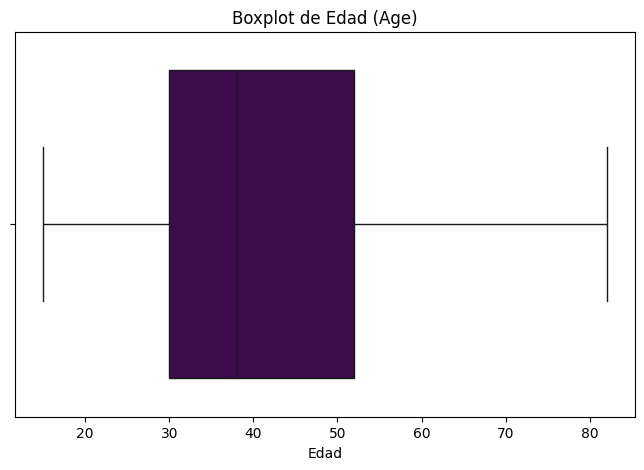

In [22]:
# Boxplot de la edad
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_thyroid['Age'])
plt.title('Boxplot de Edad (Age)')
plt.xlabel('Edad')
plt.show()



El análisis de IQR para la variable Age no identificó valores atípicos (outliers). Todos los registros se encuentran dentro del rango esperado (entre el límite inferior y superior calculado), lo cual es consistente con lo observado en el boxplot, confirmando que la distribución de edades no presenta valores extremos.


**Recomendación como responsable de la decisión.** No hay nada que depurar en la edad: el rango completo [15, 82] es clínicamente plausible y no aparecen valores imposibles (edades negativas, ceros o de tres cifras) que delaten errores de captura. Se conserva la variable tal cual y se deja para el punto 10 la decisión de escalarla, que es lo que de verdad afecta a los modelos basados en distancia. Ahora bien, un boxplot sobre toda la población puede esconder valores que sí son raros dentro de su propio grupo, así que antes de dar el tema por cerrado conviene repetir el análisis separando por la variable objetivo, que es lo que se hace enseguida.

##### Análisis complementario de Age (histograma y outliers por clase)

El criterio IQR pide revisar al menos dos columnas numéricas, pero este dataset solo tiene una: `Age`. Las otras 16 variables son categóricas, y aplicarles IQR no tendría sentido porque sus códigos numéricos aparecen apenas después del encoding y son etiquetas, no magnitudes.

Para no quedarnos con una sola revisión, aplicamos el mismo criterio a `Age` **separada por la variable objetivo**. Esto es más exigente que el análisis global: un valor puede ser perfectamente normal en la población completa y ser raro dentro de su grupo.

In [23]:
# IQR de Age dentro de cada clase de la variable objetivo
for clase in df_thyroid['Recurred'].unique():
    edades = df_thyroid.loc[df_thyroid['Recurred'] == clase, 'Age']

    q1_clase = edades.quantile(0.25)
    q3_clase = edades.quantile(0.75)
    iqr_clase = q3_clase - q1_clase

    lower_clase = q1_clase - 1.5 * iqr_clase
    upper_clase = q3_clase + 1.5 * iqr_clase

    outliers_clase = edades[(edades < lower_clase) | (edades > upper_clase)]

    print(f"Recurred = {clase}  (n = {edades.shape[0]})")
    print(f"  Q1: {q1_clase} | Q3: {q3_clase} | IQR: {iqr_clase}")
    print(f"  Límites: [{lower_clase:.2f}, {upper_clase:.2f}]")
    print(f"  Outliers: {outliers_clase.shape[0]} -> {sorted(outliers_clase.tolist())}")
    print(f"  Edad promedio: {edades.mean():.2f}\n")

Recurred = No  (n = 256)
  Q1: 28.75 | Q3: 46.25 | IQR: 17.5
  Límites: [2.50, 72.50]
  Outliers: 4 -> [73, 75, 76, 81]
  Edad promedio: 38.78

Recurred = Yes  (n = 108)
  Q1: 31.75 | Q3: 62.0 | IQR: 30.25
  Límites: [-13.62, 107.38]
  Outliers: 0 -> []
  Edad promedio: 47.11



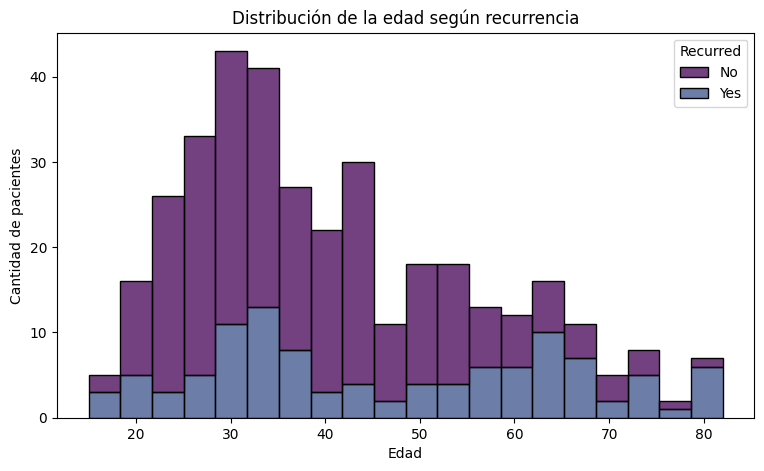

In [24]:
# Histograma de Age separado por recurrencia
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df_thyroid,
    x='Age',
    hue='Recurred',
    bins=20,
    multiple='stack',
    palette=color_palette[:2]
)
plt.title('Distribución de la edad según recurrencia')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pacientes')
plt.show()

**Interpretación.** Al mirar cada clase por separado aparecen 4 outliers que el análisis global no mostraba, y todos están en el grupo **sin recurrencia**: pacientes de 73, 75, 76 y 81 años, por encima del límite superior de 72.5 de ese grupo. En el grupo **con recurrencia** no hay ningún outlier, y la razón se ve en el IQR: 30.25 años contra 17.5 del grupo sin recurrencia. Es decir, los pacientes que recaen están mucho más dispersos en edad (rango intercuartílico de 31.75 a 62 años), así que casi ninguna edad les resulta "extrema".

El histograma refuerza la misma idea: la masa de pacientes sin recurrencia se concentra entre los 25 y los 45 años, mientras que las recurrencias se reparten de forma mucho más plana y ganan peso relativo después de los 50. Las medias lo confirman: 38.78 años sin recurrencia contra 47.11 con recurrencia.

**Decisión: se documentan, no se eliminan.** Tres razones:

1. Un paciente de 81 años con cáncer de tiroides es clínicamente posible, no es un error de captura. No hay edades negativas, ni de 200, ni fechas mal parseadas; el rango completo [15, 82] es coherente.
2. Son solo 4 registros de 364 (1.1%). Eliminarlos no cambiaría las métricas, pero sí quitaría justamente la franja etaria donde la recurrencia es más probable, que es información valiosa para el modelo.
3. Los modelos que vamos a entrenar toleran bien estos valores: los árboles y ensambles parten por umbrales y no por magnitudes, y para KNN el `StandardScaler` ya deja Age en un rango comparable al resto de columnas.

**Recomendación como responsable de la decisión:** no depurar estos casos, pero sí marcarlos para el equipo clínico. Si el modelo se lleva a producción, los pacientes mayores de 70 años son un subgrupo con muy pocos datos, así que las predicciones sobre ellos deberían revisarse manualmente hasta acumular más casos.

##### Outliers en las variables ordinales

El criterio IQR pide revisar al menos dos columnas numéricas, y `Age` es la única numérica del dataset original. Sin embargo, cuatro de las categóricas (`Risk`, `T`, `N` y `Stage`) sí van a entrar al modelo como números, porque en el punto 9 se decide codificarlas con Ordinal Encoding respetando su orden clínico. Una vez codificadas son columnas numéricas de pleno derecho, y tiene sentido revisarlas igual que se hizo con la edad.

El orden que se usa aquí no se aprende de los datos: viene de la clasificación TNM y de la categorización de riesgo del propio sistema médico. Por eso aplicarlo antes de la partición no introduce fuga de datos, ya que no hay ningún parámetro estimado a partir del dataset.

In [25]:
# IQR sobre las variables ordinales, usando el orden clínico que se definirá en el punto 9
ordenes_ordinales = {
    'Risk': ['Low', 'Intermediate', 'High'],
    'T': ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],
    'N': ['N0', 'N1a', 'N1b'],
    'Stage': ['I', 'II', 'III', 'IVA', 'IVB']
}

for col, orden in ordenes_ordinales.items():
    codigos = df_thyroid[col].map({categoria: i for i, categoria in enumerate(orden)})

    q1_ord = codigos.quantile(0.25)
    q3_ord = codigos.quantile(0.75)
    iqr_ord = q3_ord - q1_ord

    lower_ord = q1_ord - 1.5 * iqr_ord
    upper_ord = q3_ord + 1.5 * iqr_ord

    outliers_ord = codigos[(codigos < lower_ord) | (codigos > upper_ord)]
    categorias_marcadas = sorted({orden[v] for v in outliers_ord})

    print(f"{col}")
    print(f"  Q1: {q1_ord} | Q3: {q3_ord} | IQR: {iqr_ord}")
    print(f"  Límites: [{lower_ord}, {upper_ord}]")
    print(f"  Outliers: {outliers_ord.shape[0]} ({outliers_ord.shape[0] / len(df_thyroid) * 100:.1f}%)")
    print(f"  Categorías marcadas: {categorias_marcadas if categorias_marcadas else 'ninguna'}\n")

Risk
  Q1: 0.0 | Q3: 1.0 | IQR: 1.0
  Límites: [-1.5, 2.5]
  Outliers: 0 (0.0%)
  Categorías marcadas: ninguna

T
  Q1: 2.0 | Q3: 3.0 | IQR: 1.0
  Límites: [0.5, 4.5]
  Outliers: 74 (20.3%)
  Categorías marcadas: ['T1a', 'T4a', 'T4b']

N
  Q1: 0.0 | Q3: 2.0 | IQR: 2.0
  Límites: [-3.0, 5.0]
  Outliers: 0 (0.0%)
  Categorías marcadas: ninguna

Stage
  Q1: 0.0 | Q3: 0.0 | IQR: 0.0
  Límites: [0.0, 0.0]
  Outliers: 50 (13.7%)
  Categorías marcadas: ['II', 'III', 'IVA', 'IVB']



**Interpretación.** Los resultados se parten en dos grupos:

| Variable | Outliers | Categorías marcadas |
|---|---|---|
| Risk | 0 | ninguna |
| N | 0 | ninguna |
| T | 74 (20.3%) | T1a, T4a, T4b |
| Stage | 50 (13.7%) | II, III, IVA, IVB |

`Risk` y `N` no marcan nada: sus tres categorías están lo bastante repartidas como para que el rango intercuartílico las cubra todas.

`T` marca los dos extremos a la vez: los tumores más pequeños (T1a, 46 pacientes) y los más invasivos (T4a con 20 y T4b con 8). Que el criterio señale las dos puntas simultáneamente es la pista de que no está detectando errores, sino simplemente las categorías menos frecuentes de la escala.

**El caso de `Stage` es el más llamativo y sirve de advertencia metodológica.** El 86.3% de los pacientes está en estadio I, así que Q1 y Q3 valen lo mismo y el IQR da **cero**. Con un IQR de cero los límites se cierran sobre el propio estadio I, y el criterio termina marcando como atípico a *todo paciente que no sea estadio I*: 50 pacientes, el 13.7%. Es el mismo tipo de fallo que aparece en el notebook de vuelos con el precio, solo que al revés: allá el IQR se infla al mezclar dos poblaciones y no detecta casi nada, y aquí se colapsa por el desbalance y detecta de más. La lección es la misma en los dos casos: el IQR asume una distribución razonablemente repartida, y cuando esa condición no se cumple el número que devuelve no significa lo que uno cree.

**Decisión: no se elimina ninguno.** Estos "outliers" no son errores de captura sino categorías clínicas legítimas que resultan poco frecuentes en esta cohorte. Eliminarlas sería contraproducente: los 18 pacientes de estadio III en adelante recayeron todos, así que son precisamente los casos que más información aportan sobre la recurrencia. Lo mismo pasa con T4a y T4b, con tasas de recurrencia del 95% y del 100%.

**Recomendación.** Conservar todos los registros, pero dejar documentado que T3b, T4a, T4b y los estadios III, IVA y IVB tienen menos de 20 pacientes cada uno. El modelo va a contar con poca evidencia sobre esos subgrupos, así que sus predicciones ahí deberían revisarse manualmente. Si más adelante se quisiera un modelo más estable, la vía sería agrupar esas categorías (un único nivel "T4" y otro "III+"), asumiendo que se pierde granularidad a cambio de estimaciones menos ruidosas.

#### Gráficos EDA

Para identificar cuáles variables son más importantes para hacer el EDA, se calcula la relación que tienen con la variable objetivo (Recurrencia). Se seleccionan las 5 variables con mayor relación, puesto que son las de mayor influencia. De esta forma, nos enfocamos en las características que realmente importan para el modelo.

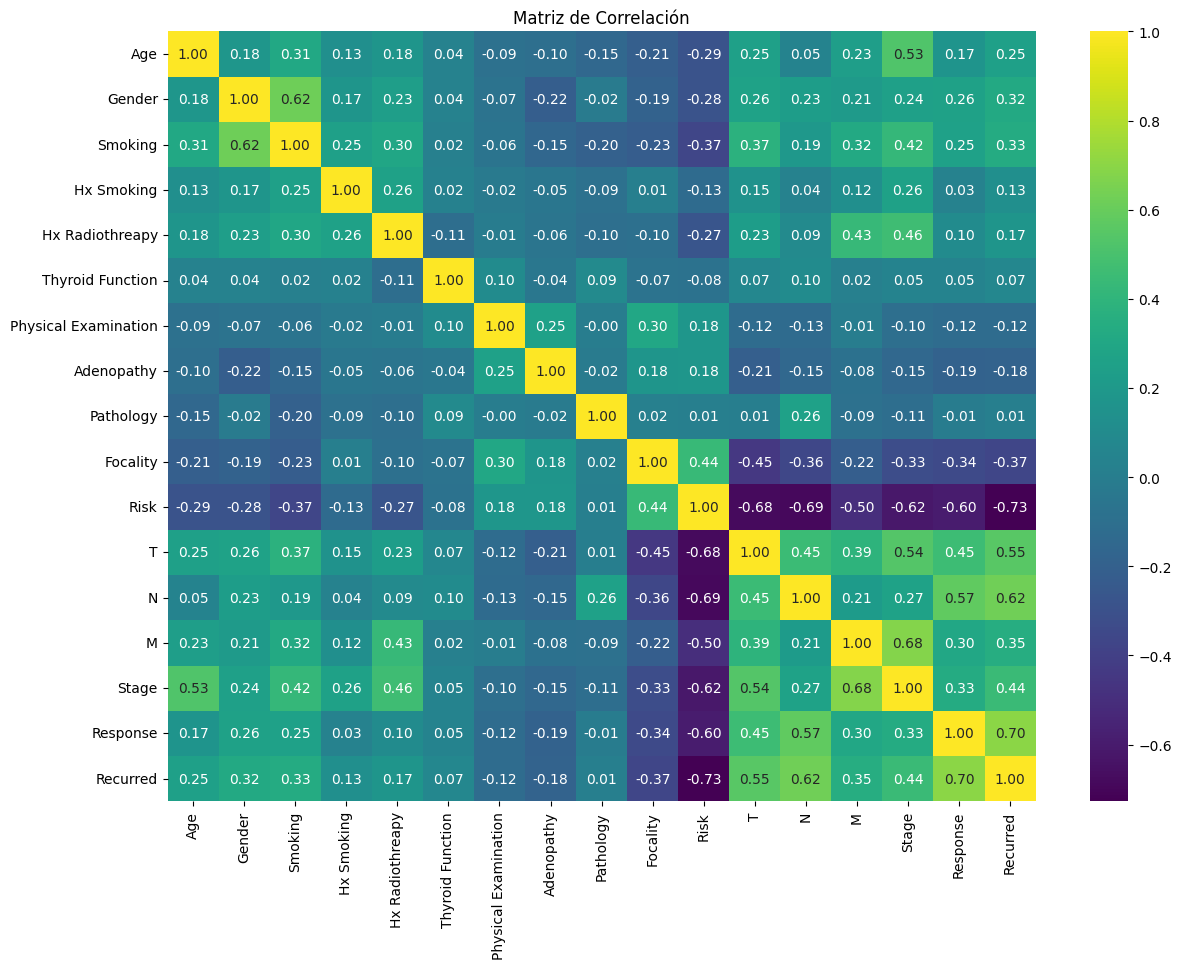

In [26]:
# Codificar variables categóricas para poder calcular la correlación
df_encoded = df_thyroid.copy()
label_encoder = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include='object').columns
for col in categorical_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# Matriz de correlación
correlation_matrix = df_encoded.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='viridis')
plt.title('Matriz de Correlación')
plt.show()


Las variables que presentan mayor correlación con la recurrencia son: **Riesgo (Risk), Respuesta al tratamiento (Response) y Clasificación de nodos (N)**. Aunque la clasificación del tumor (T) también muestra correlación, se decide incluir **Estado (Stage)** para explorar variables distintas. Y si es **Fumador (Smoking)** 

El mapa de correlación también confirma nuestra hipótesis inicial: **Fumar (Smoking) y el historial de fumar no tienen una relación tan alta con la recurrencia**, lo que indica que otros factores clínicos son más determinantes que el tabaquismo.

**Recomendación como responsable de la decisión.** La matriz de correlación sirve para priorizar qué variables mirar primero, pero no para descartar ninguna, y por dos razones. La primera es que estos coeficientes se calcularon sobre categóricas convertidas a números con LabelEncoder, que asigna los códigos en orden alfabético y no según el orden real de la variable; para algo como Pathology o Physical Examination ese número no significa nada. La segunda es que una variable muy desbalanceada produce correlaciones bajas aunque su efecto sea grande, que es justamente lo que pasa con Smoking: solo el 13.5% de la cohorte fuma. Por eso la decisión es usar este mapa únicamente para elegir las cinco variables que se grafican en detalle, y sacar las conclusiones de las tasas de recurrencia condicionales que se ven en esas gráficas, no del coeficiente.

##### Graficas EDA Risk

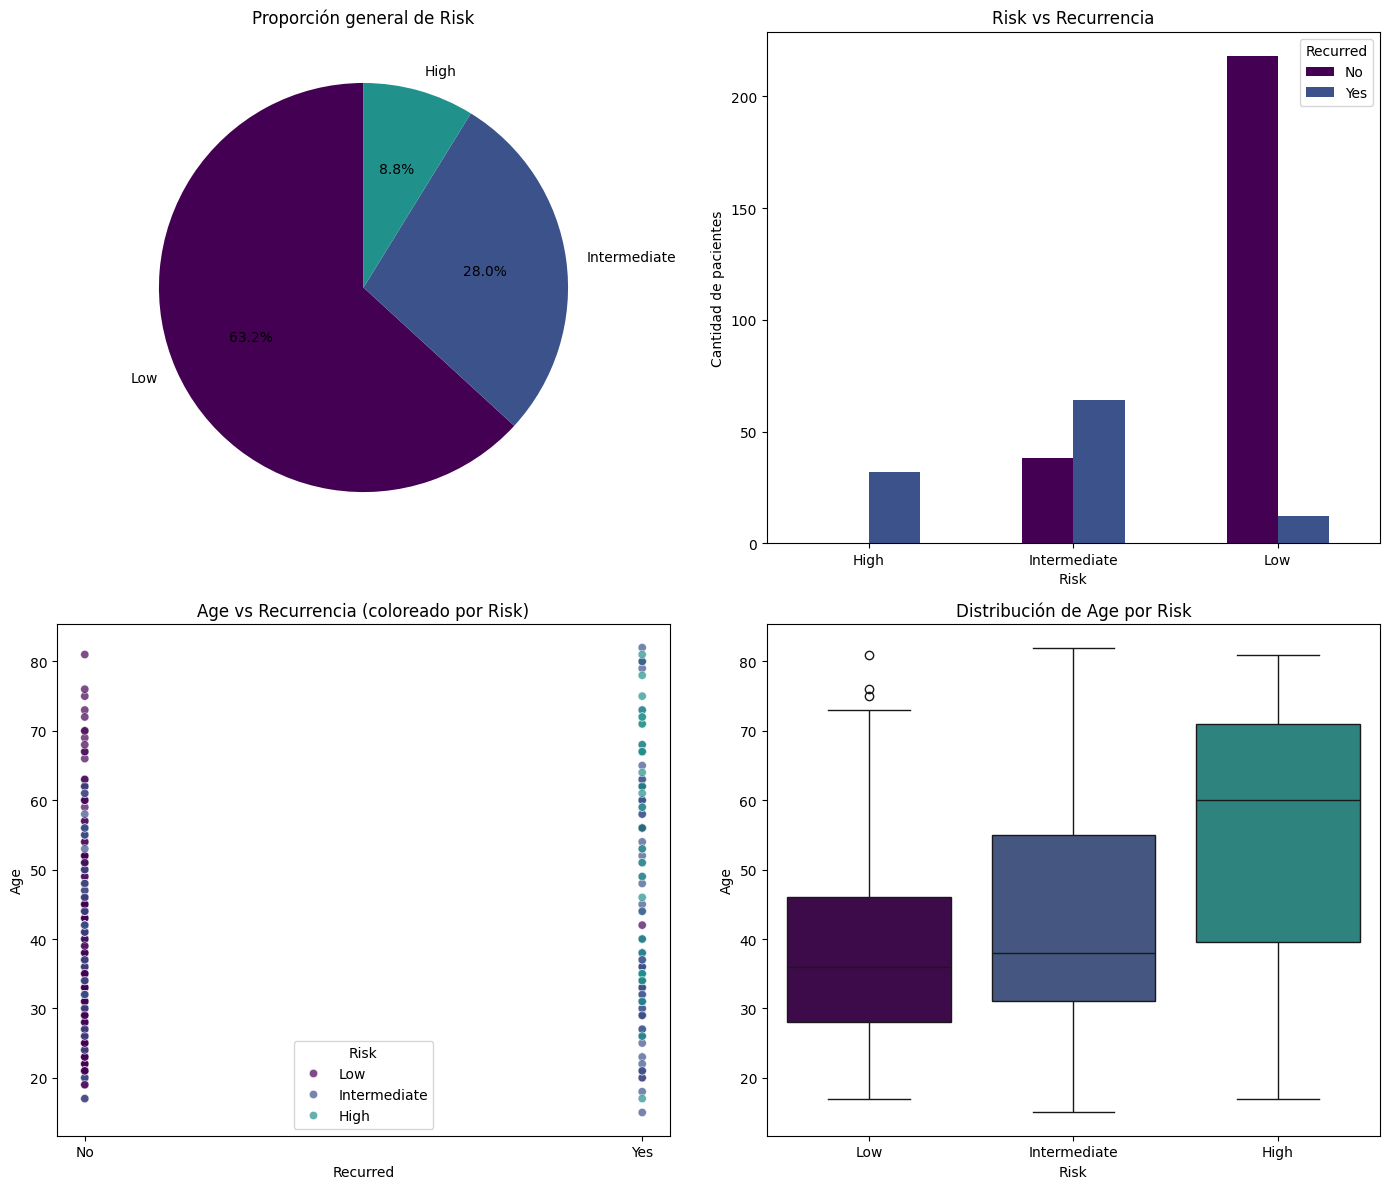

In [27]:
# Grilla 2x2 para el análisis de la variable Risk
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de Risk
risk_counts = df_thyroid['Risk'].value_counts()
axes[0, 0].pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de Risk')

# 2. Barras agrupadas - Risk vs Recurred
risk_recurred = pd.crosstab(df_thyroid['Risk'], df_thyroid['Recurred'])
risk_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('Risk vs Recurrencia')
axes[0, 1].set_xlabel('Risk')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por Risk
risk_categories = df_thyroid['Risk'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='Risk',
    data=df_thyroid,
    palette=color_palette[:risk_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por Risk)')

# 4. Boxplot - Age por Risk
sns.boxplot(
    x='Risk',
    y='Age',
    hue='Risk',
    data=df_thyroid,
    palette=color_palette[:risk_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por Risk')

plt.tight_layout()
plt.show()


**Interpretación.** La distribución general muestra que la cohorte está dominada por pacientes de bajo riesgo: 230 de 364 (63.2%) son Low, 102 (28.0%) Intermediate y solo 32 (8.8%) High. Pero el cruce contra la recurrencia es donde está la señal fuerte:

| Risk | No recurre | Recurre | % recurrencia |
|---|---|---|---|
| Low | 218 | 12 | **5.2%** |
| Intermediate | 38 | 64 | **62.7%** |
| High | 0 | 32 | **100%** |

La categoría High separa perfectamente: los 32 pacientes clasificados como alto riesgo recayeron, sin una sola excepción. En el otro extremo, un paciente Low tiene apenas 1 probabilidad entre 20 de recaer. El salto de 5.2% a 62.7% al pasar de Low a Intermediate es de más de doce veces, lo que confirma por qué esta fue una de las variables más correlacionadas con el target.

El scatter y el boxplot de Age agregan un matiz: la edad mediana sube conforme sube el riesgo, pero las tres categorías se solapan bastante, así que **Risk no es simplemente un proxy de la edad**; está capturando información clínica adicional (tamaño, invasión, histología).

**Recomendación.** Risk debe entrar al modelo con codificación ordinal (Low < Intermediate < High), porque su orden es justamente lo que lleva la información. Para la operación del hospital, esta sola variable ya sirve como regla de triage: todo paciente Intermediate o High debería entrar automáticamente al protocolo de seguimiento intensivo, sin esperar al modelo. Hay que advertir, eso sí, que High tiene solo 32 casos con separación perfecta, lo que puede llevar a los árboles a apoyarse demasiado en esa rama; conviene vigilar ese comportamiento en validación.

##### Graficas EDA Response

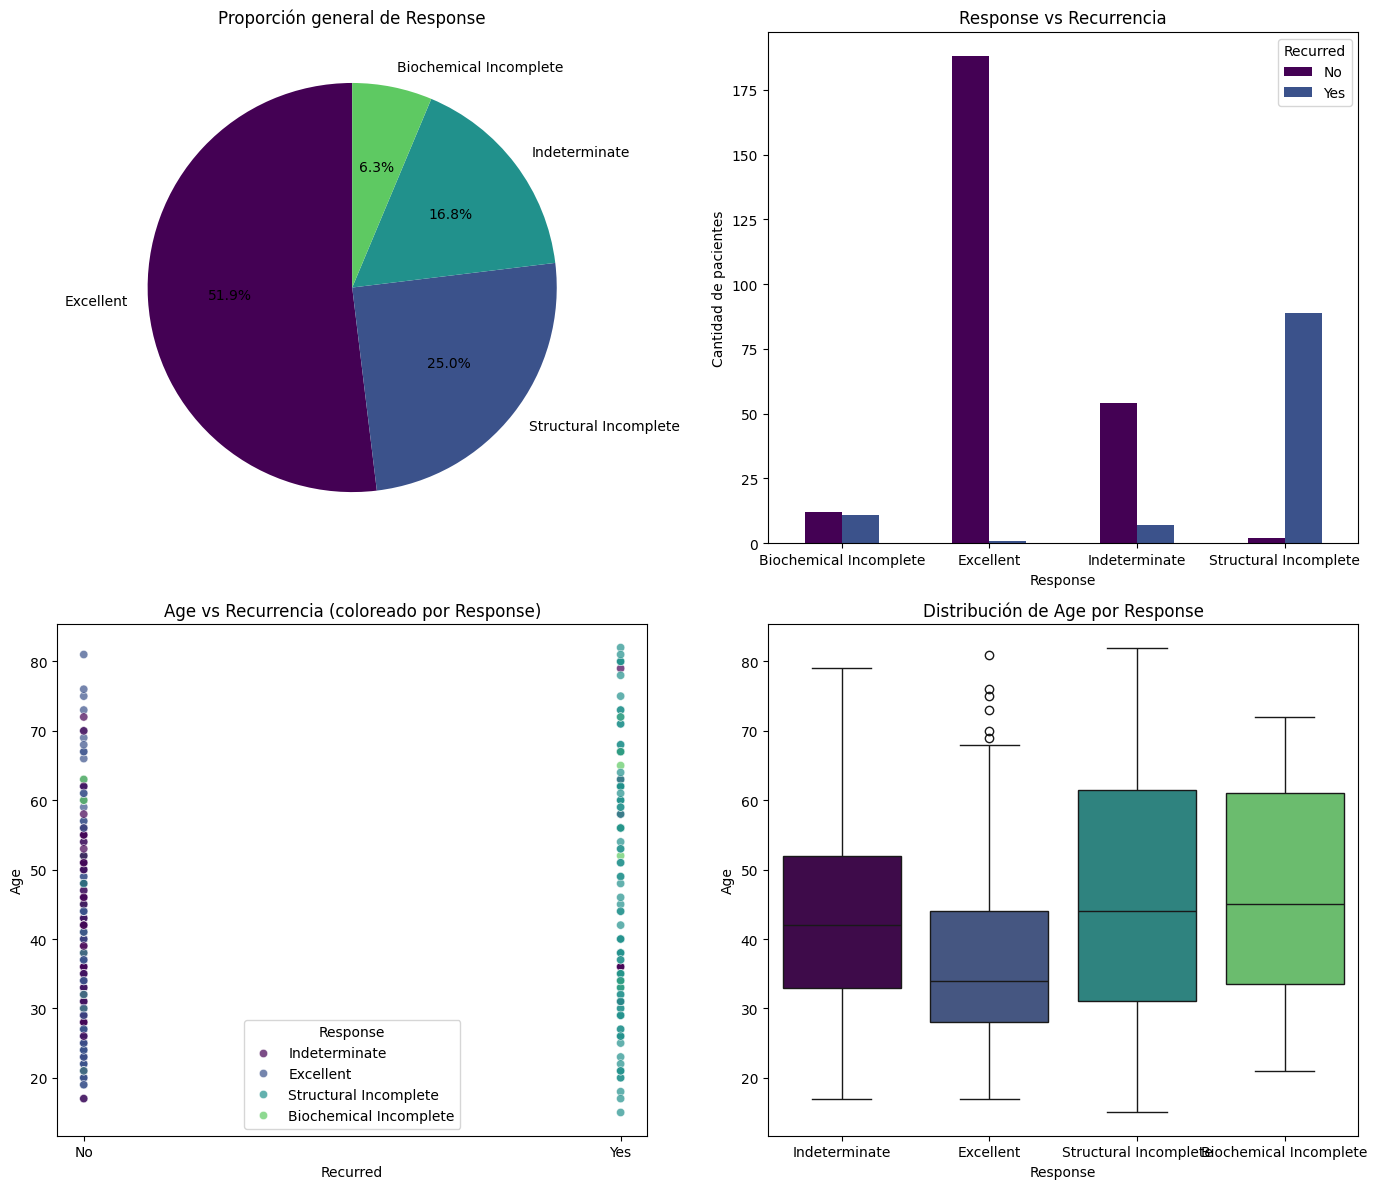

In [28]:
# Grilla 2x2 para el análisis de la variable Response
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de Response
response_counts = df_thyroid['Response'].value_counts()
axes[0, 0].pie(
    response_counts,
    labels=response_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de Response')

# 2. Barras agrupadas - Response vs Recurred
response_recurred = pd.crosstab(df_thyroid['Response'], df_thyroid['Recurred'])
response_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('Response vs Recurrencia')
axes[0, 1].set_xlabel('Response')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por Response
response_categories = df_thyroid['Response'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='Response',
    data=df_thyroid,
    palette=color_palette[:response_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por Response)')

# 4. Boxplot - Age por Response
sns.boxplot(
    x='Response',
    y='Age',
    hue='Response',
    data=df_thyroid,
    palette=color_palette[:response_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por Response')

plt.tight_layout()
plt.show()


- **Distribución de Respuesta al Tratamiento:** La mayoría de los pacientes (51.9%) mostró una respuesta "Excellent" al tratamiento, lo que indica que más de la mitad respondió favorablemente. Sin embargo, una porción significativa (25%) tuvo una respuesta "Structural Incomplete", es decir, el cáncer no fue completamente eliminado. El 16.8% tuvo respuesta "Indeterminate" y apenas el 6.3% presentó "Biochemical Incomplete". Esta distribución muestra un resultado general positivo, aunque casi la mitad de los pacientes requiere seguimiento más cuidadoso.

- **Response y Recurrencia:** El Factor Predictor Más Fuerte: Los pacientes con respuesta "Excellent" tienen una tasa de recurrencia extremadamente baja, con casi 190 pacientes sin recurrencia y solo un puñado con recurrencia. En contraste, aquellos con "Structural Incomplete" muestran principalmente el color azul en el gráfico de barras, indicando que la mayoría recurrió. Los de respuesta "Indeterminate" se ubican en el medio con tasas de recurrencia significativas. Esto tiene sentido clínico: si el tratamiento no eliminó completamente el cáncer, la probabilidad de que recurra es mucho mayor.

- **El Patrón en el Scatter Plot:** El gráfico de dispersión es muy revelador. El lado izquierdo (pacientes sin recurrencia) está prácticamente dominado por el color morado oscuro (Excellent response), confirmando que quienes respondieron bien al tratamiento casi no recurrieron. El lado derecho (con recurrencia) muestra una mezcla de colores más diversa, con predominancia de azul y cyan, representando respuestas Indeterminate y Structural Incomplete. Nuevamente, la edad está distribuida uniformemente, sugiriendo que la respuesta al tratamiento es más importante que la edad para predecir recurrencia.

- **La Edad Sí Marca una Diferencia Aquí:** El boxplot muestra que los pacientes con respuesta "Excellent" tienen una mediana de edad de 34 años, bastante por debajo de los 44 de "Structural Incomplete" y los 45 de "Biochemical Incomplete". Son unos 10 años de diferencia entre quienes responden bien y quienes no, así que a diferencia de otras variables, aquí la edad sí aporta algo: los pacientes más jóvenes tienden a responder mejor al tratamiento. Aun así las cajas se solapan bastante, de modo que por sí sola la edad no alcanza para predecir la respuesta.

- **Recomendación Clínica:** Los pacientes con respuesta Excellent pueden seguir protocolos de vigilancia estándar, mientras que aquellos con Structural Incomplete o Indeterminate requieren seguimiento intensivo y posiblemente terapias complementarias. Esta variable debe ser central en cualquier modelo predictivo de recurrencia.

##### Graficas EDA N (Clasificación de nodos):

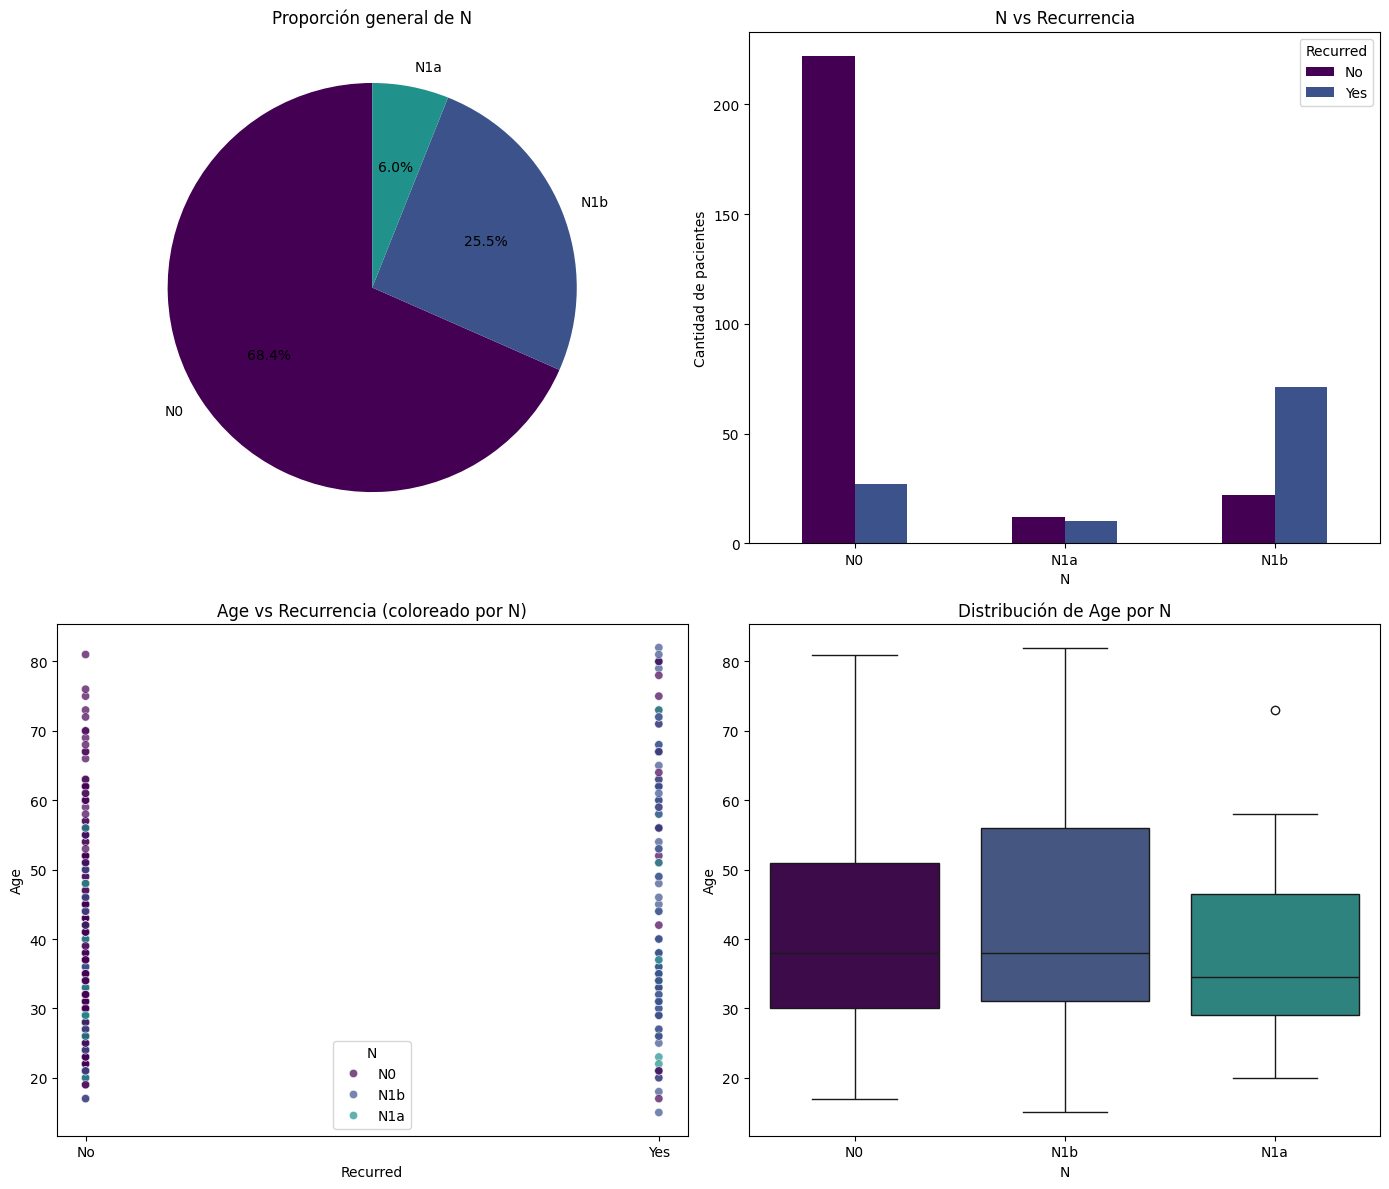

In [29]:
# Grilla 2x2 para el análisis de la variable N
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de N
n_counts = df_thyroid['N'].value_counts()
axes[0, 0].pie(
    n_counts,
    labels=n_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de N')

# 2. Barras agrupadas - N vs Recurred
n_recurred = pd.crosstab(df_thyroid['N'], df_thyroid['Recurred'])
n_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('N vs Recurrencia')
axes[0, 1].set_xlabel('N')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por N
n_categories = df_thyroid['N'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='N',
    data=df_thyroid,
    palette=color_palette[:n_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por N)')

# 4. Boxplot - Age por N
sns.boxplot(
    x='N',
    y='Age',
    hue='N',
    data=df_thyroid,
    palette=color_palette[:n_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por N')

plt.tight_layout()
plt.show()


- **Distribución de Afección de Nodos:** La clasificación de nodos linfáticos muestra que la mayoría de los pacientes (68.4%) tienen N0, es decir, sin afección de nodos linfáticos. Esto es clínicamente favorable. Sin embargo, una cuarta parte (25.5%) presenta N1b, que indica afección de nodos linfáticos bilaterales o con características más agresivas. Solo el 6% tiene N1a, representando afección mínima de nodos. Esta distribución sugiere que aunque la mayoría de pacientes no tiene metástasis ganglionares, hay un grupo significativo con afección nodal que requiere mayor vigilancia.

- **N y Recurrencia: Un Predictor Importante:** Existe una relación clara entre la clasificación de nodos y la recurrencia, aunque menos dramática que en Response. Los pacientes con N0 muestran principalmente el color morado en el gráfico de barras agrupadas, indicando tasas de recurrencia relativamente bajas. En contraste, N1b presenta más color azul, mostrando tasas de recurrencia más altas. Los pacientes con N1a, siendo pocos, muestran una distribución más equilibrada. Este patrón tiene sentido clínico: la presencia de afección ganglionar aumenta el riesgo de diseminación y, por lo tanto, de recurrencia.

- **El Scatter Plot: Predominancia de N0 sin Recurrencia:** En el gráfico de dispersión, el lado izquierdo (sin recurrencia) está mayoritariamente coloreado de morado, representando N0. El lado derecho (con recurrencia) muestra una mezcla más diversa con presencia notable de azul y cyan, representando N1a y N1b. Nuevamente, la edad está distribuida uniformemente en ambos lados, refirmando que la clasificación nodal es más importante que la edad para predecir recurrencia.

- **Edades Prácticamente Iguales Según Clasificación Nodal:** El boxplot muestra que las tres categorías tienen medianas de edad muy parecidas: 38 años para N0, 34.5 para N1a y 38 para N1b. La diferencia entre ellas es de apenas tres años y medio y las cajas se solapan casi por completo, así que la edad no ayuda a anticipar si un paciente va a tener afección ganglionar. Toda la capacidad predictiva de N viene de la afección ganglionar en sí, no de la edad.

- **Recomendación Clínica:** La clasificación nodal N es un predictor moderadamente fuerte de recurrencia. Pacientes con N0 pueden seguir protocolos estándar de seguimiento, mientras que aquellos con N1a o especialmente N1b deben someterse a vigilancia más intensiva. N debe ser incluida en el modelo predictivo, aunque probablemente con menos peso que Response.

##### Graficas EDA Stage

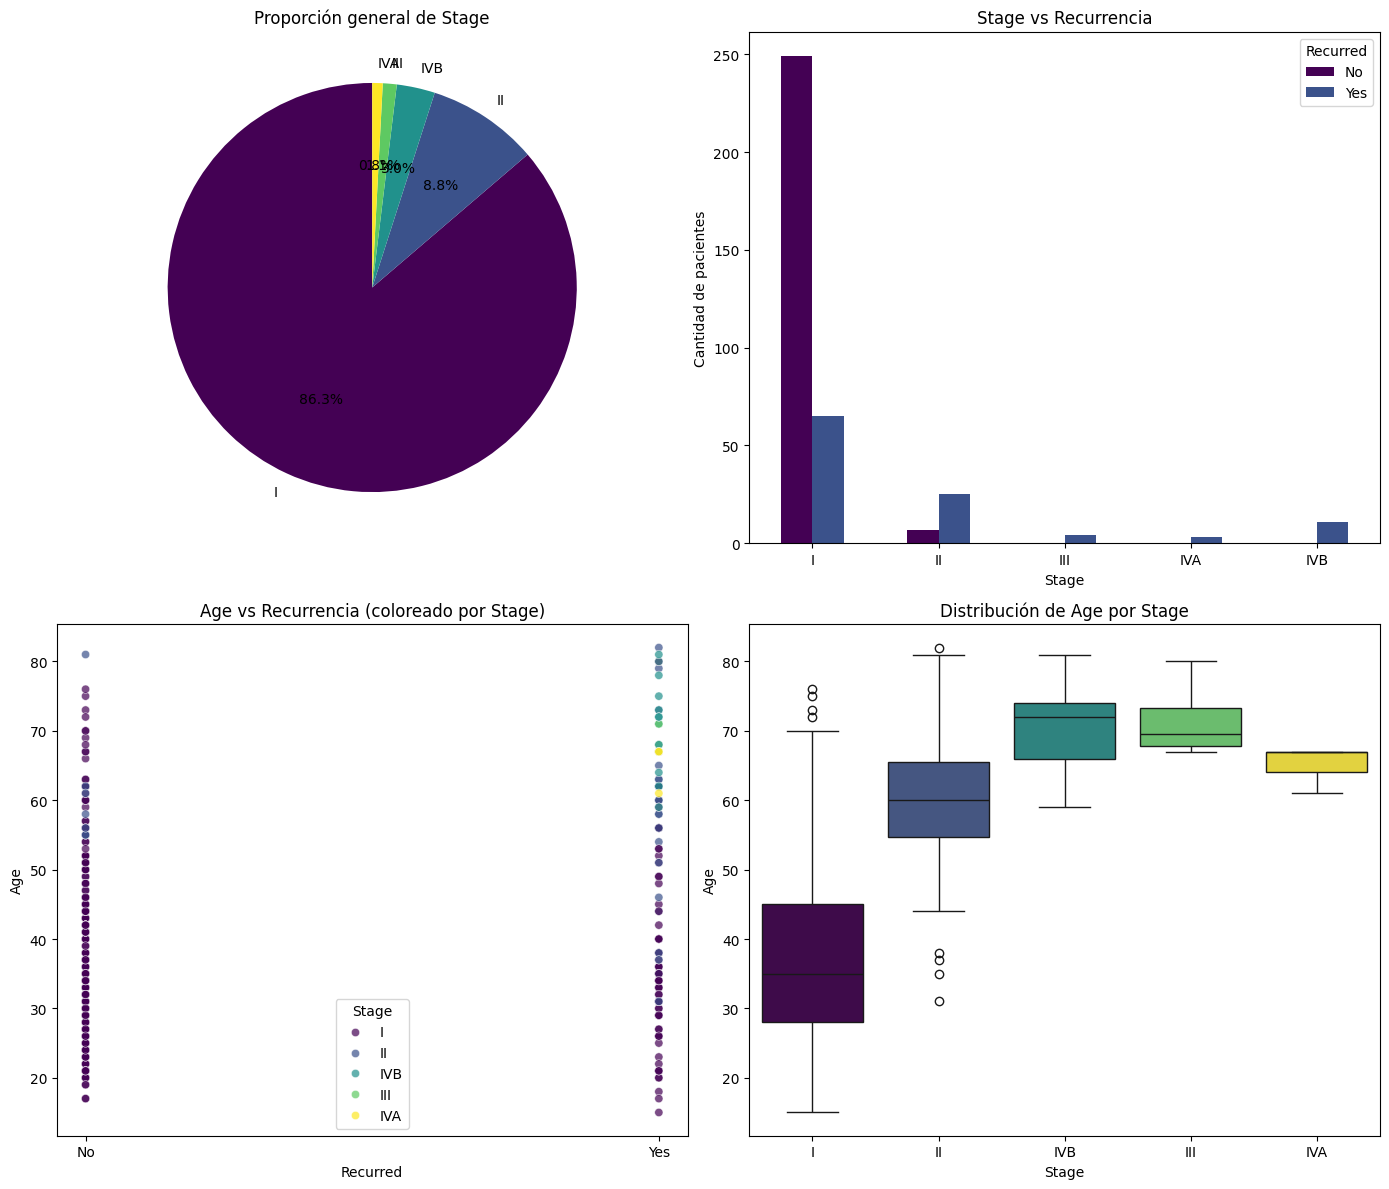

In [30]:
# Grilla 2x2 para el análisis de la variable Stage
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de Stage
stage_counts = df_thyroid['Stage'].value_counts()
axes[0, 0].pie(
    stage_counts,
    labels=stage_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de Stage')

# 2. Barras agrupadas - Stage vs Recurred
stage_recurred = pd.crosstab(df_thyroid['Stage'], df_thyroid['Recurred'])
stage_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('Stage vs Recurrencia')
axes[0, 1].set_xlabel('Stage')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por Stage
stage_categories = df_thyroid['Stage'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='Stage',
    data=df_thyroid,
    palette=color_palette[:stage_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por Stage)')

# 4. Boxplot - Age por Stage
sns.boxplot(
    x='Stage',
    y='Age',
    hue='Stage',
    data=df_thyroid,
    palette=color_palette[:stage_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por Stage')

plt.tight_layout()
plt.show()


**Interpretación.** Stage resume el estadio general del cáncer, y el cruce muestra un problema típico de este tipo de variables: el desbalance extremo.

| Stage | No recurre | Recurre | % recurrencia | n |
|---|---|---|---|---|
| I | 249 | 65 | 20.7% | 314 |
| II | 7 | 25 | 78.1% | 32 |
| III | 0 | 4 | 100% | 4 |
| IVA | 0 | 3 | 100% | 3 |
| IVB | 0 | 11 | 100% | 11 |

El 86.3% de la cohorte está en estadio I, y los estadios III, IVA y IVB juntos suman apenas 18 pacientes. La tendencia es la esperada clínicamente (a mayor estadio, más recurrencia) y de hecho todos los pacientes de estadio III en adelante recayeron, pero **ese 100% se apoya en muy pocos casos**: con 3 pacientes en IVA, un solo caso distinto cambiaría la tasa del 100% al 67%.

Comparada con Risk o con Response, Stage aporta menos, porque el estadio I concentra tanto a los pacientes que recaen como a los que no (65 y 249 respectivamente); es decir, saber que alguien es estadio I casi no reduce la incertidumbre.

**Recomendación.** Se mantiene como variable ordinal (I < II < III < IVA < IVB), que respeta la semántica del sistema TNM, pero no debe presentarse como una variable confiable por sí sola. Si se quisiera usar en un reporte clínico, lo prudente sería **agrupar III, IVA y IVB en una sola categoría "III+"**, que tendría 18 pacientes y una tasa estimada con menos ruido. Para el modelo la dejamos completa porque los ensambles manejan bien las categorías raras, pero cualquier conclusión sobre estadios avanzados en este estudio se sostiene sobre una muestra mínima.

##### Graficas EDA Smoking

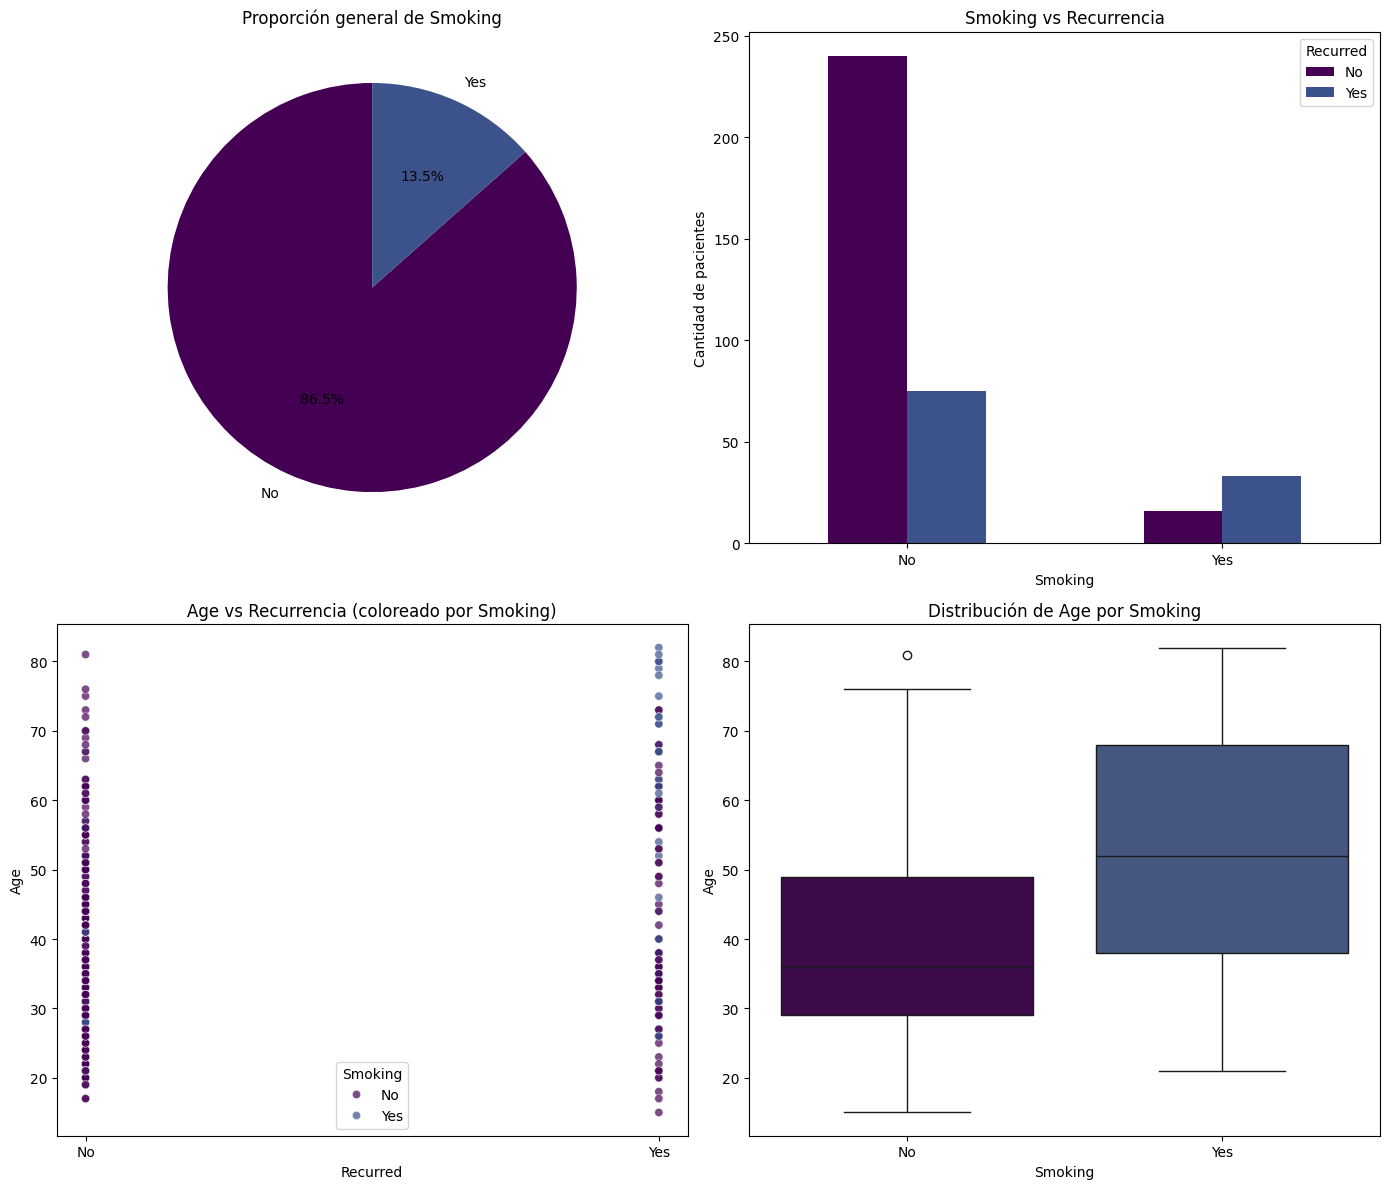

In [31]:
# Grilla 2x2 para el análisis de la variable Smoking
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de Smoking
smoking_counts = df_thyroid['Smoking'].value_counts()
axes[0, 0].pie(
    smoking_counts,
    labels=smoking_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de Smoking')

# 2. Barras agrupadas - Smoking vs Recurred
smoking_recurred = pd.crosstab(df_thyroid['Smoking'], df_thyroid['Recurred'])
smoking_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('Smoking vs Recurrencia')
axes[0, 1].set_xlabel('Smoking')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por Smoking
smoking_categories = df_thyroid['Smoking'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='Smoking',
    data=df_thyroid,
    palette=color_palette[:smoking_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por Smoking)')

# 4. Boxplot - Age por Smoking
sns.boxplot(
    x='Smoking',
    y='Age',
    hue='Smoking',
    data=df_thyroid,
    palette=color_palette[:smoking_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por Smoking')

plt.tight_layout()
plt.show()


**Interpretación.** Esta gráfica es la más interesante del EDA porque matiza la hipótesis inicial. En el mapa de correlación, Smoking aparecía con una relación débil frente a la recurrencia, y de ahí se concluyó que el tabaquismo no era determinante. Sin embargo, al mirar las tasas condicionales:

| Smoking | No recurre | Recurre | % recurrencia | n |
|---|---|---|---|---|
| No | 240 | 75 | 23.8% | 315 |
| Yes | 16 | 33 | **67.3%** | 49 |

Un fumador recae casi el triple de veces que un no fumador. La correlación salía baja no porque la relación sea débil, sino porque **solo el 13.5% de la cohorte fuma**: una variable tan desbalanceada produce coeficientes de correlación pequeños aunque el efecto condicional sea grande. Es un buen recordatorio de que la matriz de correlación, calculada sobre categóricas codificadas con LabelEncoder, es apenas una guía y no una prueba.

Ahora bien, antes de concluir que fumar causa recurrencia hay dos factores de confusión evidentes en los propios datos:

- **Sexo:** de los 49 fumadores, 40 son hombres. Y los hombres, como grupo, recaen en el 59.2% de los casos frente al 22.5% de las mujeres.
- **Edad:** la edad promedio de los fumadores es 53.1 años contra 39.4 de los no fumadores, y ya vimos que la recurrencia aumenta con la edad.

O sea que buena parte del "efecto tabaquismo" podría ser en realidad efecto de ser hombre y de ser mayor.

**Recomendación.** Smoking se conserva como variable predictora (aporta señal y su codificación binaria cuesta una sola columna), pero **no debe comunicarse como un factor causal** en ningún reporte al área clínica. Para afirmar algo así haría falta un análisis estratificado por sexo y edad, o un modelo con términos de interacción, y con 49 fumadores la muestra no da para eso. La conclusión honesta es que el tabaquismo es un **marcador de riesgo** en esta cohorte, y que coincide con perfiles (hombres mayores) que de por sí tienen peor pronóstico.

#### Tecnicas de codificación

| Columna | ¿Tiene Orden Natural? | Cardinalidad | Encoding Recomendado | Justificación |
|---------|----------------------|--------------|----------------------|---------------|
| Gender | No | 2 | Binary Encoding | Solo 2 valores, sin orden |
| Smoking | No | 2 | Binary Encoding | Solo 2 valores (Sí/No), sin orden |
| Hx Smoking | No | 2 | Binary Encoding | Solo 2 valores, sin orden |
| Hx Radiotherapy | No | 2 | Binary Encoding | Solo 2 valores, sin orden |
| Thyroid Function | No | 5 | One-Hot Encoding | 5 categorías sin orden natural |
| Physical Examination | No | 5 | One-Hot Encoding | 5 categorías, sin jerarquía |
| Adenopathy | No | 6 | One-Hot Encoding | 6 categorías distintas, sin orden |
| Pathology | No | 4 | One-Hot Encoding | Tipos histológicos sin orden |
| Focality | No | 2 | Binary Encoding | Solo 2 valores (Uni/Multi) |
| Risk | Sí | 3 | Ordinal Encoding | Hay orden: Low < Intermediate < High |
| T | Sí | 7 | Ordinal Encoding | Clasificación TNM con orden natural |
| N | Sí | 3 | Ordinal Encoding | Clasificación TNM con orden natural |
| M | No | 2 | Binary Encoding | Solo 2 valores (Ausencia/Presencia) |
| Stage | Sí | 5 | Ordinal Encoding | Estadios: I < II < III < IV |
| Response | No | 4 | One-Hot Encoding | Tipos de respuesta, sin orden |

#### Escalamiento

Es necesario el escalonado, porque el dataset contiene una única variable numérica continua: **Age (Edad)**, con rango [15-82 años]. Aunque no se detectaron outliers significativos en el análisis del punto 7, el escalado es necesario por dos razones principales**:

1. **Sensibilidad de los algoritmos**: Se entrenarán modelos como KNN y Regresión Logística, que son altamente sensibles a la escala de las variables. Sin escalado, las diferencias en la métrica de distancia estarían dominadas por Age.

2. **Desproporción después del encoding**: Tras el encoding de variables categóricas (Ordinal Encoding para Risk, Stage, T, N; Binary Encoding para Gender, Smoking, etc.), tenemos:
   - **Age**: [15-82] → rango muy grande
   - **Risk (Ordinal)**: [1, 2, 3] → rango pequeño
   - **Gender (Binary)**: [0, 1] → rango muy pequeño
   
   Esta desproporción hace que Age domine completamente el cálculo de distancias en KNN, mientras que las variables categóricas encoded quedan prácticamente ignoradas.

Se elige **StandardScaler** porque:
- **No hay outliers detectados** (por lo tanto, RobustScaler no es necesario)
- Estandariza Age a media=0 y desviación estándar=1
- Transforma el rango [15-82] a aproximadamente [-2.5 a +2.5]
- Es la técnica más adecuada para distribuiciones normales sin outliers extremos
- Mejora la convergencia en algoritmos iterativos (Regresión Logística)
- Mantiene la interpretabilidad de los coeficientes

### **Fase 2 - División de datos y Pipelines**


In [32]:
# Separar variable objetivo del resto de features
X = df_thyroid.drop(columns=['Recurred'])
y = df_thyroid['Recurred']

# Primera partición: 70% train, 30% restante (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Segunda partición: dividir el 30% restante en 15% val y 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(df_thyroid):.1%})")
print(f"Validation: {X_val.shape[0]} muestras ({X_val.shape[0]/len(df_thyroid):.1%})")
print(f"Test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(df_thyroid):.1%})")


Train: 254 muestras (69.8%)
Validation: 55 muestras (15.1%)
Test: 55 muestras (15.1%)


Dividimos el dataset en tres conjuntos porque cada uno cumple un propósito distinto dentro del ciclo de vida del modelo:

- **Train (70%):** es el conjunto con el que el modelo aprende, es decir, donde se ajustan sus parámetros internos (pesos, coeficientes, reglas de decisión, etc.).
- **Validation (15%):** se usa durante el desarrollo del modelo para comparar configuraciones y ajustar hiperparámetros (por ejemplo, profundidad de un árbol, número de vecinos en KNN, regularización, etc.), sin tocar el conjunto de test. Nos permite elegir el mejor modelo de forma "justa", sin haber visto los datos finales de evaluación.
- **Test (15%):** se reserva para el final, y se usa una única vez para medir el desempeño real del modelo ya elegido, simulando cómo se comportaría con datos completamente nuevos.

**¿Por qué no basta con solo train/test?**
Si solo tuviéramos train y test, y usáramos el test repetidamente para probar distintas configuraciones de hiperparámetros, estaríamos indirectamente "filtrando" información del test hacia el proceso de entrenamiento (overfitting al conjunto de test). El modelo terminaría luciendo mejor de lo que realmente es, porque fue ajustado (aunque sea indirectamente, por prueba y error) para funcionar bien específicamente en esos datos de test. Al tener un conjunto de validación independiente, el test se mantiene "limpio" y su resultado es una estimación honesta del rendimiento del modelo en producción.



#### Pipeline

In [33]:
# Numérica: escalamiento
numeric_features = ['Age']

# Binarias (2 categorías, sin orden): Binary Encoding
binary_features = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Focality', 'M']

# Nominales (más de 2 categorías, sin orden): One-Hot Encoding
onehot_features = ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Response']

# Ordinales (con orden natural): Ordinal Encoding
ordinal_features = ['Risk', 'T', 'N', 'Stage']

# Orden explícito de las categorías ordinales
risk_order = ['Low', 'Intermediate', 'High']
t_order = ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
n_order = ['N0', 'N1a', 'N1b']
stage_order = ['I', 'II', 'III', 'IVA', 'IVB']

In [34]:
# Pipeline numérico: imputación por mediana + escalamiento
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline binario: imputación por moda + Binary Encoding
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', BinaryEncoder())
])

# Pipeline nominal: imputación por moda + One-Hot Encoding
onehot_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline ordinal: imputación por moda + Ordinal Encoding con orden definido
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[risk_order, t_order, n_order, stage_order]))
])


In [35]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('bin', binary_pipeline, binary_features),
    ('onehot', onehot_pipeline, onehot_features),
    ('ord', ordinal_pipeline, ordinal_features)
])


In [36]:
# Ajustar SOLO con train
X_train_processed = preprocessor.fit_transform(X_train)

# Aplicar la misma transformación ya ajustada a validation y test
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Train shape: {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")


Train shape: (254, 41)
Validation shape: (55, 41)
Test shape: (55, 41)


**Verificación de ausencia de Data Leakage**

En la implementación del preprocesamiento se garantizó que no existe fuga de datos (data leakage) entre los conjuntos de train, validation y test, siguiendo estas reglas:

- El .fit() se ejecutó únicamente sobre X_train: la línea preprocessor.fit_transform(X_train) es la única vez que el ColumnTransformer (y todos los pasos internos: SimpleImputer, StandardScaler, OrdinalEncoder, OneHotEncoder, BinaryEncoder) aprende parámetros a partir de los datos — por ejemplo, la mediana/moda para imputar valores faltantes, la media y desviación estándar de Age para escalar, y las categorías vistas para los encoders.
- Sobre X_val y X_test solo se aplicó .transform(): las líneas preprocessor.transform(X_val) y preprocessor.transform(X_test) reutilizan los parámetros ya aprendidos en el paso anterior, sin recalcular nada nuevo a partir de esos datos.
- No se volvió a llamar fit() ni fit_transform() en ningún punto posterior sobre validation o test, lo cual asegura que esos conjuntos permanecen "no vistos" por el preprocesador durante su ajuste, tal como ocurriría con datos completamente nuevos en producción.

Gracias a este flujo (fit solo en train → transform en train/val/test), ninguna estadística de validation o test (como su media, su moda o sus categorías) influye en la transformación de los datos de entrenamiento, evitando que el modelo obtenga una ventaja artificial al momento de evaluarse.



### **Fase 4 - Modelado: Clasificación (Thyroid Disease Data)**

In [37]:
# Diccionario con los modelos a entrenar
models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42), 
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', C=1.0, probability=True, random_state=42),
}

trained_models = {}

# Entrenamiento con barra de progreso (% de modelos completados)
for name, model in tqdm(models.items(), desc='Entrenando modelos'):
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    elapsed_time = time.time() - start_time
    trained_models[name] = model
    print(f"{name} entrenado en {elapsed_time:.4f} segundos")


Entrenando modelos: 100%|██████████| 6/6 [00:00<00:00, 56.40it/s]

KNN entrenado en 0.0012 segundos
Decision Tree entrenado en 0.0010 segundos
Random Forest entrenado en 0.0641 segundos
Gradient Boosting entrenado en 0.0347 segundos
SVM (RBF) entrenado en 0.0029 segundos
SVM (Linear) entrenado en 0.0019 segundos


### **Fase 5 - Métricas en train y validación: detección de overfitting/underfitting**

In [38]:
# Calcular métricas de clasificación en train y validation para cada modelo
positive_label = 'Yes'
results = []

for name, model in trained_models.items():
    # Predicciones
    y_train_pred = model.predict(X_train_processed)
    y_val_pred = model.predict(X_val_processed)

    # Índice de la clase positiva para predict_proba (necesario para ROC-AUC)
    positive_idx = list(model.classes_).index(positive_label)
    y_train_proba = model.predict_proba(X_train_processed)[:, positive_idx]
    y_val_proba = model.predict_proba(X_val_processed)[:, positive_idx]

    # Métricas en train
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, pos_label=positive_label)
    train_recall = recall_score(y_train, y_train_pred, pos_label=positive_label)
    train_f1 = f1_score(y_train, y_train_pred, pos_label=positive_label)
    train_auc = roc_auc_score(y_train.map({'No': 0, 'Yes': 1}), y_train_proba)

    # Métricas en validation
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, pos_label=positive_label)
    val_recall = recall_score(y_val, y_val_pred, pos_label=positive_label)
    val_f1 = f1_score(y_val, y_val_pred, pos_label=positive_label)
    val_auc = roc_auc_score(y_val.map({'No': 0, 'Yes': 1}), y_val_proba)

    results.append({
        'Model': name,
        'Train Accuracy': train_accuracy, 'Val Accuracy': val_accuracy,
        'Train Precision': train_precision, 'Val Precision': val_precision,
        'Train Recall': train_recall, 'Val Recall': val_recall,
        'Train F1': train_f1, 'Val F1': val_f1,
        'Train AUC': train_auc, 'Val AUC': val_auc
    })

results_df = pd.DataFrame(results).round(4)
results_df


,Model,Train Accuracy,Val Accuracy,Train Precision,Val Precision,Train Recall,Val Recall,Train F1,Val F1,Train AUC,Val AUC
0,KNN,0.9370,0.8727,0.9683,0.9167,0.8133,0.6471,0.8841,0.7586,0.9864,0.9745
1,Decision Tree,1.0000,0.9091,1.0000,0.8000,1.0000,0.9412,1.0000,0.8649,1.0000,0.9180
2,Random Forest,1.0000,0.9636,1.0000,0.9412,1.0000,0.9412,1.0000,0.9412,1.0000,0.9923
3,Gradient Boosting,1.0000,0.9091,1.0000,0.8000,1.0000,0.9412,1.0000,0.8649,1.0000,0.9923
4,SVM (RBF),0.9606,0.9636,0.9851,1.0000,0.8800,0.8824,0.9296,0.9375,0.9978,0.9907
5,SVM (Linear),0.9646,0.9636,0.9714,0.9412,0.9067,0.9412,0.9379,0.9412,0.9978,0.9892


- Decision Tree y Gradient Boosting: en train les fue perfecto, 100% en todo. Pero eso justamente es la señal de alarma: se "aprendieron de memoria" los datos de entrenamiento en vez de aprender un patrón general. Por eso, cuando les toca predecir datos que no habían visto (validation), bajan bastante, sobre todo en Precision (pasan de 100% a 80%). Esto es un caso claro de overfitting.
- Random Forest: también le fue perfecto en train, pero acá está la diferencia — en validation casi no baja (sigue con 96% de accuracy y 94% de precision y recall). O sea, aunque también "memorizó" un poco el train, es el que mejor se las arregla con datos nuevos. Es el más consistente de los cuatro.
- KNN: este no llegó a 100% en train (le fue bien pero no perfecto), así que a primera vista no parece que memorizó todo. El problema es otro: en validation su Recall se cae bastante (de 81% a solo 65%). Es decir, deja pasar muchos casos reales de recurrencia sin detectarlos, que es justo lo que no queremos.
¿Y en un tema de salud, qué es peor: un falso positivo o un falso negativo?

Si el modelo dice "no va a volver" y en realidad sí vuelve (falso negativo), el paciente no recibe seguimiento a tiempo y el cáncer puede avanzar sin que nadie se dé cuenta. Eso es grave.
Si el modelo dice "sí va a volver" y en realidad no vuelve (falso positivo), al paciente le mandan hacerse más exámenes de más, lo cual da estrés y cuesta plata, pero no le hace daño directo — es solo una molestia y un gasto extra.
Entonces está claro: es mucho peor dejar pasar un caso real de recurrencia que mandar a alguien a hacerse un examen de más. Por eso, la métrica que más nos debería importar acá es el Recall, porque es la que nos dice qué tan bien está el modelo detectando los casos reales de recurrencia (y no dejándolos pasar).

Con eso en mente, Random Forest es el que mejor queda parado: tiene el Recall más alto en validation (94%, empatado con los otros dos), pero sin sacrificar Precision como sí les pasa a Decision Tree y Gradient Boosting. Además es el que menos "se desarma" al pasar de train a validation, así que es el más confiable de los cuatro. KNN queda descartado justamente porque, aunque en general no se ve mal, es el que más casos reales de recurrencia se le escapan — y ese es el error que más nos interesa evitar.

#### Matrices de confusión (train y validación)

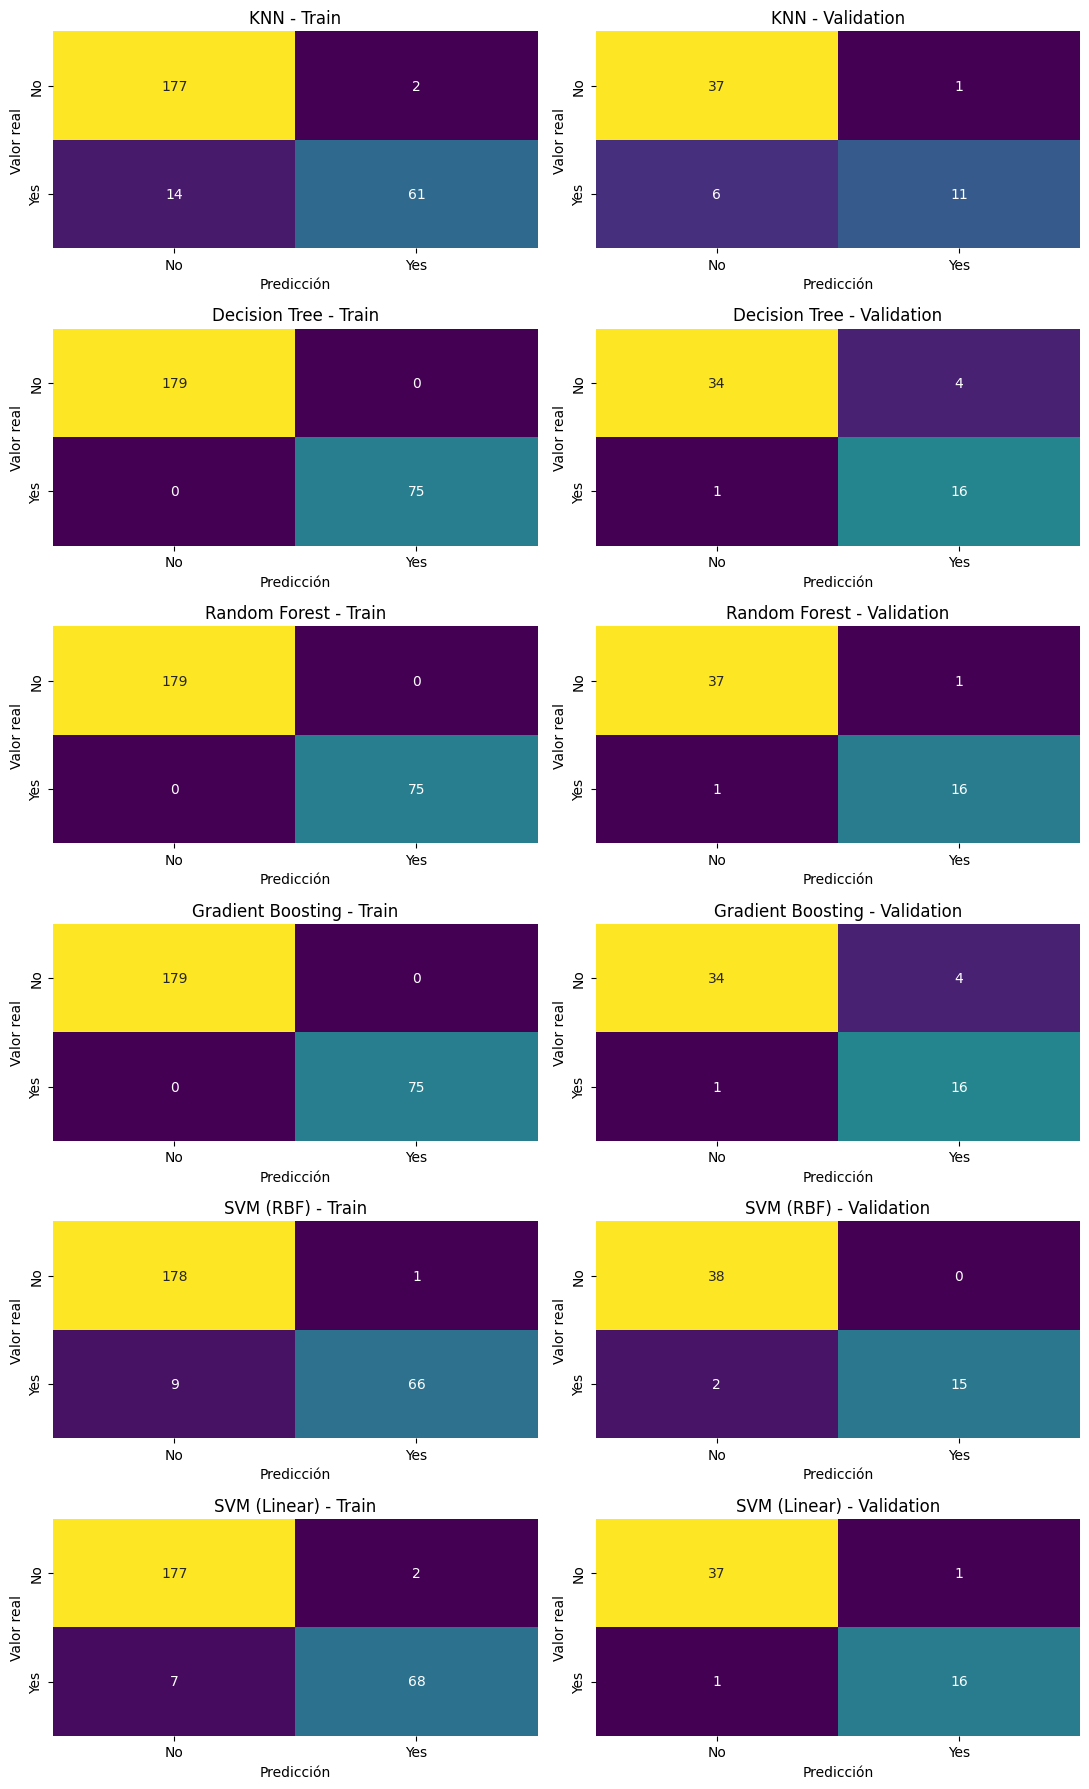

In [40]:
# Matrices de confusión en train y validación para los 4 modelos
clases = ['No', 'Yes']

fig, axes = plt.subplots(6, 2, figsize=(11, 18))

for i, (name, model) in enumerate(trained_models.items()):
    conjuntos = [
        ('Train', X_train_processed, y_train),
        ('Validation', X_val_processed, y_val)
    ]

    for j, (nombre_conjunto, X_set, y_set) in enumerate(conjuntos):
        cm = confusion_matrix(y_set, model.predict(X_set), labels=clases)

        sns.heatmap(
            cm, annot=True, fmt='d', cmap='viridis', cbar=False,
            xticklabels=clases, yticklabels=clases, ax=axes[i, j]
        )
        axes[i, j].set_title(f'{name} - {nombre_conjunto}')
        axes[i, j].set_xlabel('Predicción')
        axes[i, j].set_ylabel('Valor real')

plt.tight_layout()
plt.show()

**Lectura de las matrices en validación** (55 pacientes: 38 sin recurrencia y 17 con recurrencia):

| Modelo | VN | FP | FN | VP |
|---|---|---|---|---|
| KNN | 37 | 1 | **6** | 11 |
| Decision Tree | 34 | 4 | 1 | 16 |
| Random Forest | 37 | 1 | 1 | 16 |
| Gradient Boosting | 34 | 4 | 1 | 16 |

En train, los tres modelos basados en árboles tienen matrices perfectamente diagonales (179 y 75 aciertos, cero errores), que es la traducción visual del accuracy 1.0000 comentado arriba. KNN es el único que ya se equivoca en train: 14 falsos negativos.

**Poniéndole números a la discusión anterior.** Ya quedó establecido que el error costoso aquí es el falso negativo y que la métrica a priorizar es el Recall. Falta un matiz: tampoco se puede maximizar el recall a ciegas, porque predecir "Yes" para todos daría recall 1.0 saturando el servicio con controles innecesarios y generando angustia en pacientes sanos. El criterio práctico que adoptamos entonces es **maximizar recall usando F1 como desempate**, porque F1 castiga que la precisión se derrumbe. Las matrices permiten ver exactamente cuánto cuesta cada opción.

Con ese criterio KNN queda descartado de entrada: 6 falsos negativos de 17 significa que se le escapa uno de cada tres pacientes que van a recaer, lo cual es inaceptable clínicamente por muy bueno que sea su 0.8727 de accuracy. Entre los otros tres, los tres capturan 16 de 17 recurrencias, pero Random Forest lo logra con 1 falso positivo mientras que el árbol y el boosting necesitan 4.

#### Tabla comparativa: brechas entre train y validación

In [41]:
# Diferencia train - val por métrica (una brecha grande y positiva es señal de overfitting)
gaps = pd.DataFrame({
    'Model': results_df['Model'],
    'Gap Accuracy': results_df['Train Accuracy'] - results_df['Val Accuracy'],
    'Gap Precision': results_df['Train Precision'] - results_df['Val Precision'],
    'Gap Recall': results_df['Train Recall'] - results_df['Val Recall'],
    'Gap F1': results_df['Train F1'] - results_df['Val F1']
}).round(4)

gaps

,Model,Gap Accuracy,Gap Precision,Gap Recall,Gap F1
0,KNN,0.0643,0.0516,0.1662,0.1255
1,Decision Tree,0.0909,0.2000,0.0588,0.1351
2,Random Forest,0.0364,0.0588,0.0588,0.0588
3,Gradient Boosting,0.0909,0.2000,0.0588,0.1351
4,SVM (RBF),-0.0030,-0.0149,-0.0024,-0.0079
5,SVM (Linear),0.0010,0.0302,-0.0345,-0.0033


La tabla de la celda anterior (`results_df`) es la tabla comparativa pedida, con los cuatro modelos en filas y Accuracy, Precision, Recall, F1 y AUC en train y en validación como columnas. Esta segunda tabla resume la misma información en forma de brechas, que es lo que permite leer el overfitting de un vistazo:

- **Random Forest** tiene la brecha más pequeña y además pareja en todas las métricas (entre 0.036 y 0.059). Un desajuste uniforme y pequeño indica que el modelo generaliza, no que tenga suerte en una métrica.
- **Decision Tree** y **Gradient Boosting** comparten exactamente el mismo perfil: brecha de 0.20 en precisión, que es la más alta de la tabla, contra apenas 0.059 en recall. Traducido: los dos siguen encontrando a casi todos los pacientes que recaen, pero en datos nuevos empiezan a marcar como recurrentes a pacientes que no lo son.
- **KNN** invierte el patrón: su peor brecha está en el recall (0.166). Pierde precisamente la capacidad que más nos importa.

Conviene recordar que estas brechas se calculan sobre 55 pacientes de validación, así que un solo caso equivale a 1.8 puntos porcentuales de accuracy. Las diferencias de dos o tres centésimas entre modelos no son concluyentes por sí solas, y esa es una de las razones para hacer la validación cruzada de la Fase 7.

#### Selección del mejor modelo

In [42]:
# Tiempo de entrenamiento de cada modelo (se repite el fit para medirlo de forma comparable)
training_times = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    training_times[name] = time.time() - start_time

# Resumen con los criterios que se usan para decidir
resumen_modelos = results_df[['Model', 'Val Recall', 'Val Precision', 'Val F1', 'Val AUC']].copy()
resumen_modelos['Gap Accuracy'] = gaps['Gap Accuracy']
resumen_modelos['Tiempo entrenamiento (s)'] = resumen_modelos['Model'].map(training_times).round(4)

resumen_modelos

,Model,Val Recall,Val Precision,Val F1,Val AUC,Gap Accuracy,Tiempo entrenamiento (s)
0,KNN,0.6471,0.9167,0.7586,0.9745,0.0643,0.0011
1,Decision Tree,0.9412,0.8000,0.8649,0.9180,0.0909,0.0017
2,Random Forest,0.9412,0.9412,0.9412,0.9923,0.0364,0.0629
3,Gradient Boosting,0.9412,0.8000,0.8649,0.9923,0.0909,0.0342
4,SVM (RBF),0.8824,1.0000,0.9375,0.9907,-0.0030,0.0025
5,SVM (Linear),0.9412,0.9412,0.9412,0.9892,0.0010,0.0017


**Modelo seleccionado: Random Forest Classifier.**

La decisión no se toma solo por tener la accuracy más alta en validación; se sustenta en cuatro criterios:

**1. Es el mejor en la métrica que importa, sin sacrificar las demás.** Empata en recall con el árbol y el boosting (0.9412, es decir 16 de 17 recurrencias detectadas), pero lo hace con precisión 0.9412 frente a 0.8000 de los otros dos. Es el único que combina el recall más alto con la menor cantidad de falsos positivos, y eso lo deja con el mejor F1 (0.9412) y el mejor AUC (0.9923) del grupo.

**2. Es el que menos sobreajusta.** Los cuatro modelos parten del mismo preprocesamiento, así que la diferencia viene del algoritmo. Random Forest tiene la brecha train-val más baja (0.0364 en accuracy contra 0.0909 del árbol y del boosting). Esto es coherente con lo visto en clase: un árbol individual tiene sesgo bajo y varianza alta, y el bagging ataca justamente la varianza al promediar muchos árboles entrenados sobre muestras bootstrap distintas y con subconjuntos aleatorios de variables en cada split. El árbol solo se queda con toda su varianza, y por eso su desempeño depende tanto de qué pacientes le tocaron.

**3. Los trade-offs juegan a su favor en este dataset.**

- *Tiempo de entrenamiento:* con 254 filas y 41 columnas los cuatro modelos entrenan en fracciones de segundo, así que el costo computacional no alcanza a ser un criterio de desempate. Random Forest es de los más lentos del grupo en términos relativos (entrena 100 árboles), pero en términos absolutos son centésimas de segundo. Si el dataset creciera a cientos de miles de pacientes esta conversación cambiaría, y ahí Random Forest tendría la ventaja adicional de paralelizarse (`n_jobs=-1`), cosa que Gradient Boosting no puede hacer porque construye los árboles de forma secuencial.
- *Interpretabilidad:* aquí Random Forest pierde frente al Decision Tree, que se puede imprimir y mostrarle a un médico como una serie de reglas ("si Response = Structural Incomplete y Risk = High, entonces recurrencia"). El bosque es una caja más opaca. Se compensa parcialmente con `feature_importances_`, que sí permite explicar qué variables pesan más, y esa es la salida que graficamos en la Fase 8. Dado que el costo de un falso negativo es la salud del paciente, se prioriza el desempeño sobre la transparencia total, pero se deja el árbol simple documentado como modelo de respaldo para explicar decisiones puntuales.
- *Sensibilidad a la escala:* Random Forest no la necesita, mientras que KNN depende por completo de ella. Eso también lo hace más robusto ante cambios futuros en el preprocesamiento.

**4. Descartes explícitos.** KNN queda fuera por sus 6 falsos negativos. Decision Tree queda fuera por su varianza: mismo recall que el bosque pero cuatro veces más falsos positivos y la brecha de precisión más alta. Gradient Boosting queda fuera porque con estos números no aporta nada por encima del árbol simple (métricas idénticas en validación) y sí agrega hiperparámetros y tiempo secuencial; con un dataset más grande la conclusión podría invertirse.

### **Fase 6 - Evaluación final en el conjunto de Test**

Hasta este punto el conjunto de test no se había tocado: no participó en el `.fit()` del preprocesador, no se usó para entrenar y no se miró para elegir el modelo. Esa es la razón por la que sus métricas son una estimación honesta de cómo se comportarían los modelos con pacientes nuevos.

Se evalúan **los cuatro modelos**, no solo el ganador, porque parte del ejercicio es verificar si el ranking obtenido en validación se sostiene.

In [43]:
# Evaluación de los 4 modelos entrenados sobre el conjunto de test
test_results = []

for name, model in trained_models.items():
    y_test_pred = model.predict(X_test_processed)

    positive_idx = list(model.classes_).index(positive_label)
    y_test_proba = model.predict_proba(X_test_processed)[:, positive_idx]

    test_results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Test Precision': precision_score(y_test, y_test_pred, pos_label=positive_label),
        'Test Recall': recall_score(y_test, y_test_pred, pos_label=positive_label),
        'Test F1': f1_score(y_test, y_test_pred, pos_label=positive_label),
        'Test AUC': roc_auc_score(y_test.map({'No': 0, 'Yes': 1}), y_test_proba)
    })

test_results_df = pd.DataFrame(test_results).round(4)
test_results_df

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,KNN,0.9455,0.9333,0.8750,0.9032,0.9575
1,Decision Tree,0.9273,0.8333,0.9375,0.8824,0.9303
2,Random Forest,0.9455,0.9333,0.8750,0.9032,0.9679
3,Gradient Boosting,0.9636,0.9375,0.9375,0.9375,0.9760
4,SVM (RBF),0.9636,0.9375,0.9375,0.9375,0.9375
5,SVM (Linear),0.9818,1.0000,0.9375,0.9677,0.9455


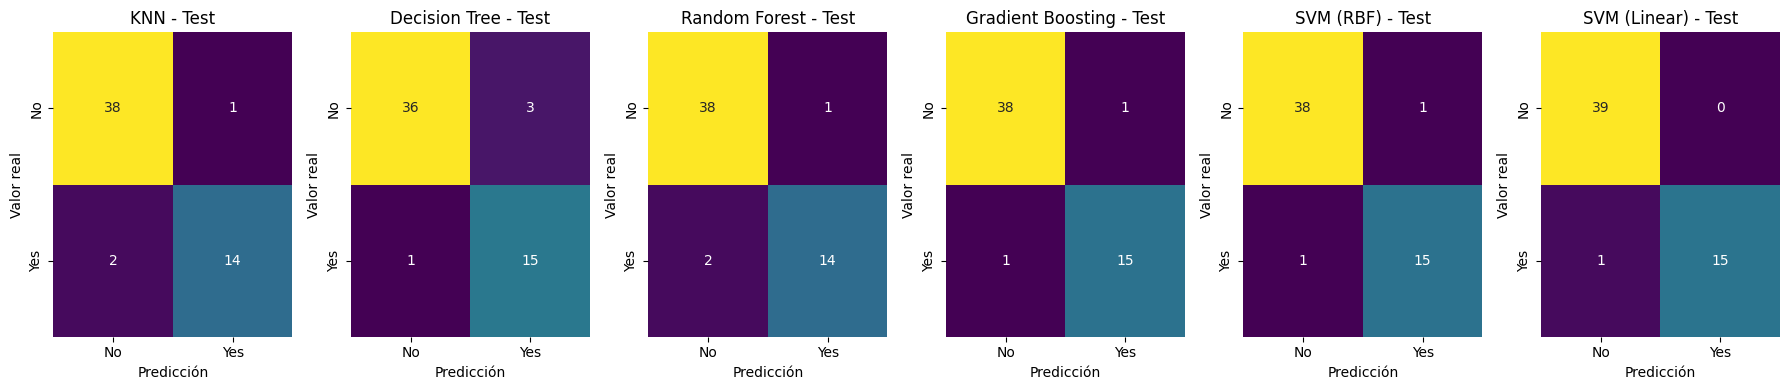

In [47]:
# Matrices de confusión sobre el conjunto de test
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

for i, (name, model) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_processed), labels=clases)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='viridis', cbar=False,
        xticklabels=clases, yticklabels=clases, ax=axes[i]
    )
    axes[i].set_title(f'{name} - Test')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Valor real')

plt.tight_layout()
plt.show()

#### Tabla comparativa final: validación vs test

In [48]:
# Comparación directa entre lo obtenido en validación y lo obtenido en test
comparacion = results_df[['Model', 'Val Accuracy', 'Val Recall', 'Val F1', 'Val AUC']].merge(
    test_results_df[['Model', 'Test Accuracy', 'Test Recall', 'Test F1', 'Test AUC']],
    on='Model'
)

# Ranking según F1 (method='min' para que los empates compartan posición)
comparacion['Ranking Val'] = comparacion['Val F1'].rank(ascending=False, method='min').astype(int)
comparacion['Ranking Test'] = comparacion['Test F1'].rank(ascending=False, method='min').astype(int)

comparacion

,Model,Val Accuracy,Val Recall,Val F1,Val AUC,Test Accuracy,Test Recall,Test F1,Test AUC,Ranking Val,Ranking Test
0,KNN,0.8727,0.6471,0.7586,0.9745,0.9455,0.8750,0.9032,0.9575,6,4
1,Decision Tree,0.9091,0.9412,0.8649,0.9180,0.9273,0.9375,0.8824,0.9303,4,6
2,Random Forest,0.9636,0.9412,0.9412,0.9923,0.9455,0.8750,0.9032,0.9679,1,4
3,Gradient Boosting,0.9091,0.9412,0.8649,0.9923,0.9636,0.9375,0.9375,0.9760,4,2
4,SVM (RBF),0.9636,0.8824,0.9375,0.9907,0.9636,0.9375,0.9375,0.9375,3,2
5,SVM (Linear),0.9636,0.9412,0.9412,0.9892,0.9818,0.9375,0.9677,0.9455,1,1


**¿Se mantiene el ranking?** No exactamente, y vale la pena entender por qué.

| Modelo | F1 val | F1 test | Puesto val | Puesto test |
|---|---|---|---|---|
| Random Forest | 0.9412 | 0.9032 | 1 | 2 |
| Gradient Boosting | 0.8649 | 0.9375 | 2 | **1** |
| Decision Tree | 0.8649 | 0.8824 | 2 | 4 |
| KNN | 0.7586 | 0.9032 | 4 | 2 |

El orden cambia: Gradient Boosting pasa del segundo puesto al primero, Random Forest baja al segundo y KNN sube del último al segundo. A primera vista parece que elegimos mal el modelo, pero al mirar las matrices de confusión el cambio es mucho menos dramático de lo que sugieren las tablas.

**El test tiene 55 pacientes, de los cuales solo 16 recayeron.** Eso significa que un solo paciente vale 1.8 puntos porcentuales de accuracy y alrededor de 6 puntos de recall. Las matrices de test muestran:

| Modelo | VN | FP | FN | VP |
|---|---|---|---|---|
| KNN | 38 | 1 | 2 | 14 |
| Decision Tree | 36 | 3 | 1 | 15 |
| Random Forest | 38 | 1 | 2 | 14 |
| Gradient Boosting | 38 | 1 | 1 | 15 |

Random Forest y Gradient Boosting se diferencian en **un solo paciente**: el bosque comete 2 falsos negativos y el boosting 1. Toda la reorganización del ranking se explica por dos o tres pacientes que cayeron de un lado o del otro. No es evidencia de que un modelo sea superior al otro, es ruido de muestreo en conjuntos pequeños.

**El AUC lo confirma**, y por eso es útil haberlo calculado: como no depende del umbral de 0.5 sino del ordenamiento completo de las probabilidades, es mucho más estable. En validación el orden fue RF = GB (0.9923) > KNN (0.9745) > DT (0.9180); en test fue GB (0.9760) > RF (0.9679) > KNN (0.9575) > DT (0.9303). Ahí el ranking sí se mantiene en lo sustancial: los dos ensambles arriba y el árbol solo abajo, en los dos conjuntos.

**¿Qué significaría una diferencia grande entre validación y test?** Significaría que la selección del modelo se sobreajustó al conjunto de validación: al comparar modelos una y otra vez sobre los mismos 55 pacientes, terminamos escogiendo el que mejor se acomoda a ese subconjunto particular y no el que mejor generaliza. Una caída fuerte (por ejemplo, F1 de 0.94 a 0.70) sería la señal de alarma. Aquí la caída del modelo elegido es de 0.9412 a 0.9032 en F1 y de 0.9636 a 0.9455 en accuracy: menos de 4 puntos, en la dirección esperada y del orden de magnitud del ruido que produce un conjunto de 55 pacientes. Es un resultado consistente.

**Lo que sí queda claro es que ningún modelo se derrumbó en test.** Los cuatro se mantienen por encima de 0.88 de F1, lo que indica que el preprocesamiento (encoding, escalado, imputación) no introdujo fuga de datos: si el `.fit()` hubiera visto el test, las métricas de test se verían artificialmente parecidas a las de train (cercanas a 1.0), y no es el caso.

### **Fase 7 - Cross Validation**

#### ¿Qué es K-Fold Cross Validation?

Hasta ahora todo el análisis se apoyó en **un solo corte** de los datos: 254 pacientes para entrenar, 55 para validar y 55 para probar. El problema es que ese corte fue una decisión aleatoria (`random_state=42`), y como se vio en la Fase 6, mover dos o tres pacientes de un conjunto a otro cambia el ranking de los modelos. Si hubiéramos usado `random_state=7`, probablemente las métricas serían distintas. Entonces, ¿cuál de las dos sería la verdadera?

La validación cruzada resuelve eso repitiendo el experimento varias veces con cortes diferentes:

1. Se toma el conjunto de datos y se parte en **K bloques (folds)** del mismo tamaño; en este caso K=5.
2. Se entrena el modelo con K-1 bloques (4 de 5, el 80% de los datos) y se evalúa con el bloque que quedó por fuera.
3. Se repite el proceso K veces, rotando cuál es el bloque de evaluación, de manera que **cada dato es usado exactamente una vez para evaluar y K-1 veces para entrenar**.
4. Al final se tienen K valores de cada métrica. Se reportan su **promedio** (la estimación del desempeño) y su **desviación estándar** (qué tan estable es ese desempeño).

**¿Por qué es más confiable que un solo split?**

- **Usa todos los datos para evaluar.** En un split simple, el 15% que quedó en validación es el único que se mide y el resto nunca se evalúa. Con 5 folds, los 309 pacientes pasan por el rol de datos no vistos.
- **Promedia el efecto de la suerte.** Un fold puede tocar pacientes difíciles y otro pacientes fáciles; el promedio de los cinco es una estimación con mucho menos varianza que cualquiera de ellos por separado.
- **Da una medida de incertidumbre.** Esto es lo que un split simple no puede dar: una desviación estándar alta significa que el modelo es sensible a qué datos le tocan, y eso es una advertencia que ninguna métrica puntual muestra.
- **Es especialmente valioso con datasets pequeños.** Con 364 registros, reservar el 15% para validar es desperdiciar información que el modelo necesita para aprender. La validación cruzada permite evaluar sin sacrificar datos de entrenamiento de forma permanente.

Usamos la variante **estratificada** (`StratifiedKFold`) porque la clase positiva es minoritaria (29.7%): si los folds se armaran de forma puramente aleatoria, alguno podría quedar con muy pocos casos de recurrencia y su recall sería inestable o indefinido.

**Nota sobre el punto 25:** la validación cruzada del mejor modelo de **regresión** corresponde al notebook de predicción de precios, no a este; aquí se desarrolla el punto 26 (cross validation sobre el mejor modelo de clasificación).

In [56]:
# El preprocesamiento va DENTRO del pipeline para que en cada fold se ajuste
# únicamente con la porción de entrenamiento de ese fold (evita fuga de datos en la CV)
best_model_name = 'Random Forest'
best_model = trained_models[best_model_name]

best_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Se usan train + validation (309 pacientes) y se deja el test por fuera
X_cv = pd.concat([X_train, X_val])
y_cv = pd.concat([y_train, y_val]).map({'No': 0, 'Yes': 1})

# StratifiedKFold mantiene la proporción de la clase objetivo en cada fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(best_model_pipeline, X_cv, y_cv, cv=skf, scoring=scoring)

cv_df = pd.DataFrame(
    {metrica: cv_results[f'test_{metrica}'] for metrica in scoring},
    index=[f'Fold {i + 1}' for i in range(skf.get_n_splits())]
)
cv_df.loc['Media'] = cv_df.mean()
cv_df.loc['Desv. estándar'] = cv_df.iloc[:skf.get_n_splits()].std()

print(f"Modelo evaluado: {best_model_name}")
print(f"Datos usados en la CV: {X_cv.shape[0]} pacientes ({int(y_cv.sum())} con recurrencia)\n")
cv_df.round(4)

Modelo evaluado: Random Forest
Datos usados en la CV: 309 pacientes (92 con recurrencia)



,accuracy,precision,recall,f1,roc_auc
Fold 1,0.9516,1.0000,0.8333,0.9091,0.9722
Fold 2,0.9839,1.0000,0.9444,0.9714,0.9962
Fold 3,0.9839,0.9500,1.0000,0.9744,1.0000
Fold 4,0.9032,1.0000,0.6842,0.8125,0.9682
Fold 5,0.9672,0.9000,1.0000,0.9474,0.9935
Media,0.9580,0.9700,0.8924,0.9229,0.9860
Desv. estándar,0.0334,0.0447,0.1348,0.0670,0.0147


**Comparación contra el split simple de la Fase 5**

| Métrica | Validación (Fase 5) | CV 5-fold (media) | Desv. estándar | Test (Fase 6) |
|---|---|---|---|---|
| Accuracy | 0.9636 | 0.9580 | 0.0334 | 0.9455 |
| Precision | 0.9412 | 0.9700 | 0.0447 | 0.9333 |
| Recall | 0.9412 | 0.8924 | **0.1348** | 0.8750 |
| F1 | 0.9412 | 0.9229 | 0.0670 | 0.9032 |
| AUC | 0.9923 | 0.9860 | 0.0147 | 0.9679 |

**¿Mejora, empeora o se mantiene?** Se mantiene en el mismo rango, pero baja ligeramente: el F1 pasa de 0.9412 a 0.9229 y el recall de 0.9412 a 0.8924. Es decir, **el split de validación era un poco optimista**. Y lo más revelador es que los valores de la CV quedan mucho más cerca de lo que después ocurrió en test (F1 0.9032, recall 0.8750) que la métrica del split único. Esto es exactamente lo que se espera: la validación cruzada da una estimación menos afortunada y más realista, porque no depende de que un corte particular haya salido favorable.

**¿El modelo es estable o sensible?** Depende de la métrica, y esa distinción es el hallazgo importante:

- En **accuracy (±0.0334)** y sobre todo en **AUC (±0.0147)** el modelo es muy estable. El AUC se mueve entre 0.9682 y 1.0000 en los cinco folds, lo que significa que la capacidad del bosque para *ordenar* pacientes por riesgo casi no depende de qué datos le tocaron.
- En **recall (±0.1348)** es claramente sensible. Los folds van de 0.6842 a 1.0000: en el fold 4 detecta 13 de 19 recurrencias, y en los folds 3 y 5 las detecta todas. Esa dispersión no es un defecto del algoritmo sino un efecto del tamaño de muestra: cada fold tiene apenas unos 18 o 19 pacientes con recurrencia, así que fallar en 3 casos ya mueve el recall 16 puntos.

**Conclusión práctica.** El desempeño real del modelo se comunica mejor como un intervalo que como un número: **F1 de 0.92 ± 0.07 y recall de 0.89 ± 0.13**, no "F1 de 0.9412". Y como el recall es la métrica que más nos importa clínicamente y es justamente la más inestable, la recomendación para una eventual puesta en producción es actuar sobre ella directamente: entrenar con `class_weight='balanced'`, bajar el umbral de decisión por debajo de 0.5 para favorecer la detección, o simplemente recolectar más casos de recurrencia. Cualquiera de las tres ataca el problema de fondo, que es que solo tenemos 108 pacientes recurrentes en total.

### **Fase 8 - Conclusiones**

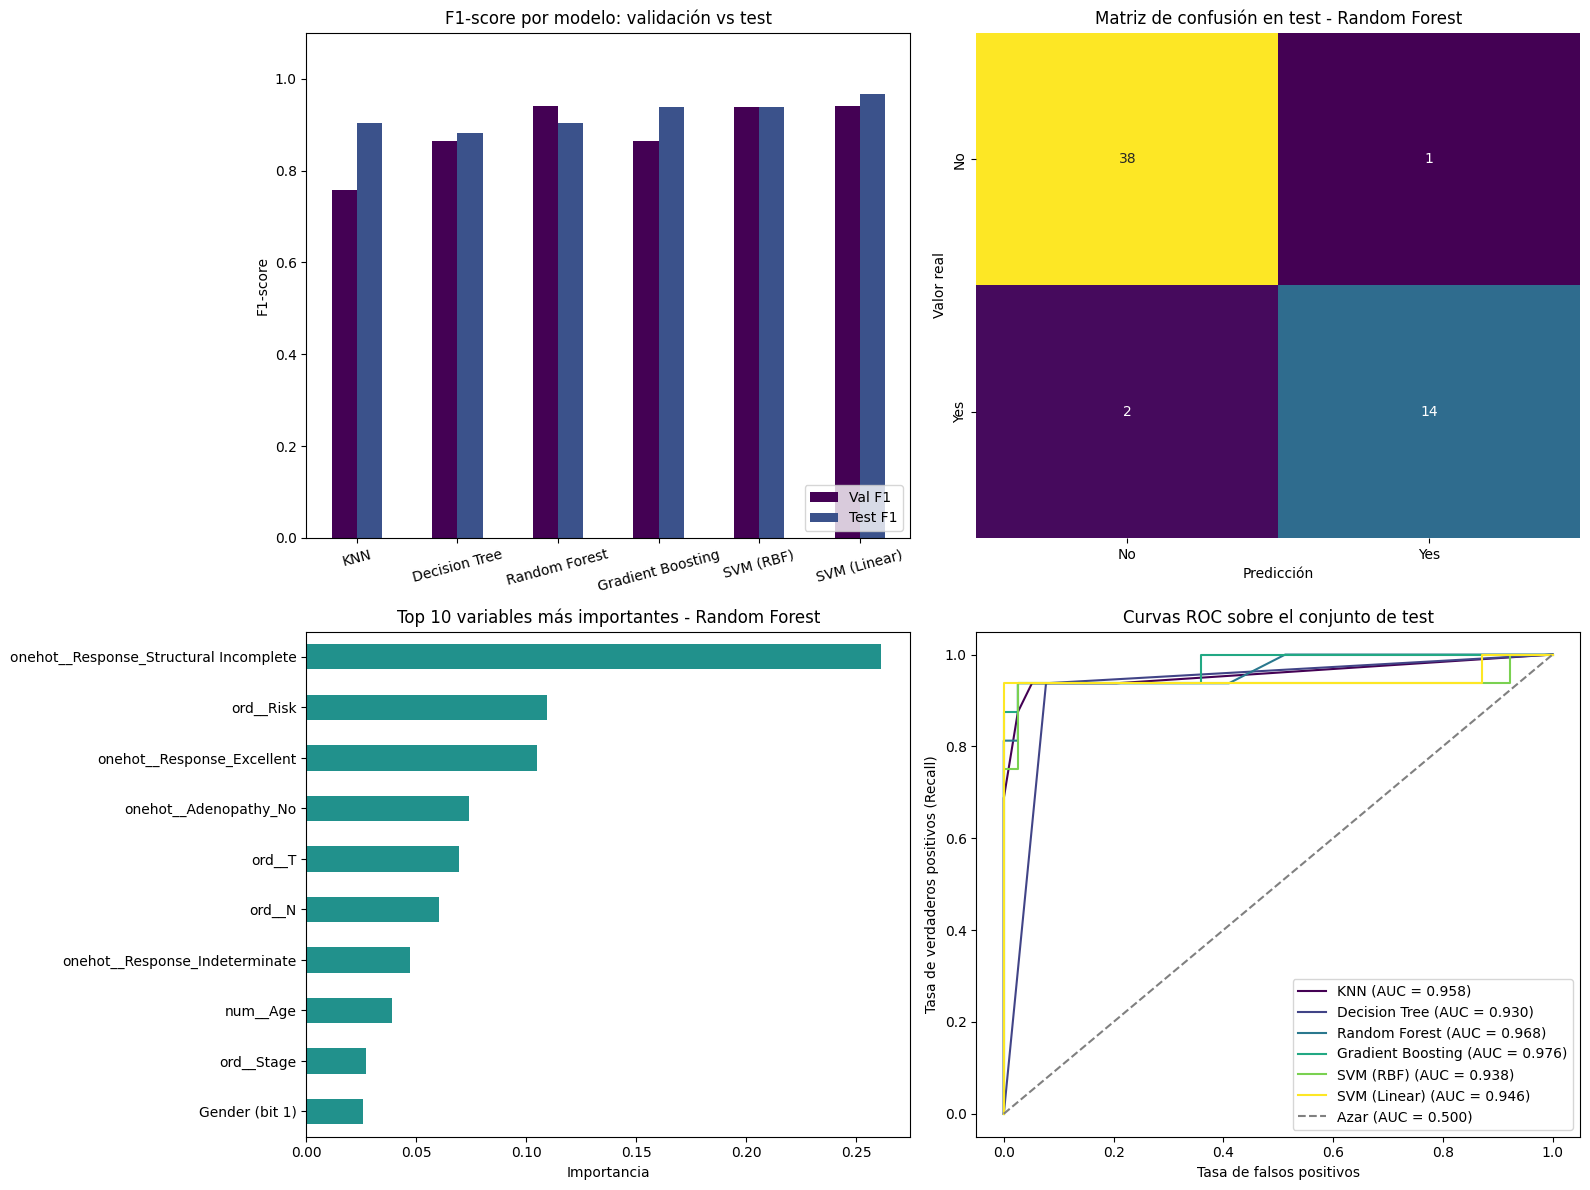

In [ ]:
# Subplot (2,2) con las gráficas que sustentan los hallazgos generales del dataset
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. F1-score de cada modelo en validación y en test
comparacion.set_index('Model')[['Val F1', 'Test F1']].plot(
    kind='bar', ax=axes[0, 0], color=color_palette[:2]
)
axes[0, 0].set_title('F1-score por modelo: validación vs test')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('F1-score')
axes[0, 0].set_ylim(0, 1.1)
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].legend(loc='lower right')

# 2. Matriz de confusión del mejor modelo sobre el test
cm_best = confusion_matrix(y_test, best_model.predict(X_test_processed), labels=clases)
sns.heatmap(
    cm_best, annot=True, fmt='d', cmap='viridis', cbar=False,
    xticklabels=clases, yticklabels=clases, ax=axes[0, 1]
)
axes[0, 1].set_title(f'Matriz de confusión en test - {best_model_name}')
axes[0, 1].set_xlabel('Predicción')
axes[0, 1].set_ylabel('Valor real')

# 3. Variables más importantes según el mejor modelo
importancias = pd.Series(
    best_model.feature_importances_,
    index=preprocessor.get_feature_names_out()
).sort_values(ascending=False).head(10)

# Las columnas binarias quedan nombradas por índice (el SimpleImputer previo devuelve
# un array sin nombres), así que se traducen para que la gráfica se pueda leer
nombres_binarias = {
    f'bin__{indice}_{bit}': f'{columna} (bit {bit})'
    for indice, columna in enumerate(binary_features)
    for bit in [0, 1]
}
importancias = importancias.rename(index=nombres_binarias)

importancias.sort_values().plot(kind='barh', ax=axes[1, 0], color=color_palette[2])
axes[1, 0].set_title(f'Top 10 variables más importantes - {best_model_name}')
axes[1, 0].set_xlabel('Importancia')

# 4. Curvas ROC de los 4 modelos sobre el test
y_test_bin = y_test.map({'No': 0, 'Yes': 1})

colores_roc = plt.cm.viridis(np.linspace(0, 1, len(trained_models)))

for i, (name, model) in enumerate(trained_models.items()):
    positive_idx = list(model.classes_).index(positive_label)
    proba = model.predict_proba(X_test_processed)[:, positive_idx]
    fpr, tpr, _ = roc_curve(y_test_bin, proba)
    auc = roc_auc_score(y_test_bin, proba)
    axes[1, 1].plot(fpr, tpr, color=colores_roc[i], label=f'{name} (AUC = {auc:.3f})')

axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC = 0.500)')
axes[1, 1].set_title('Curvas ROC sobre el conjunto de test')
axes[1, 1].set_xlabel('Tasa de falsos positivos')
axes[1, 1].set_ylabel('Tasa de verdaderos positivos (Recall)')
axes[1, 1].legend(loc='lower right')

plt.tight_layout()
plt.show()

#### Conclusiones generales

**El modelo elegido y por qué.** Para el problema de clasificación de recurrencia de cáncer de tiroides, el mejor modelo fue **Random Forest Classifier** (F1 0.9412 y AUC 0.9923 en validación; F1 0.9032 y AUC 0.9679 en test; F1 0.9229 ± 0.0670 en validación cruzada de 5 folds). La razón se explica bien con el marco de sesgo/varianza: los árboles de decisión tienen sesgo bajo pero varianza alta, y en un dataset de apenas 364 registros esa varianza es el problema dominante, no el sesgo. Random Forest ataca exactamente eso promediando 100 árboles entrenados sobre muestras bootstrap distintas y con subconjuntos aleatorios de variables en cada split, y el efecto se ve en los números: misma capacidad de detección que el árbol solo (16 de 17 recurrencias en validación) con una cuarta parte de los falsos positivos y la menor brecha train-val de los cuatro modelos (0.0364 contra 0.0909). Gradient Boosting terminó con métricas casi idénticas, y de hecho superó al bosque en test por un solo paciente, pero ataca el sesgo en lugar de la varianza, que no era la limitación aquí, y no se puede paralelizar. KNN fue el peor, y su fracaso es informativo: es el único modelo del grupo basado en distancias, y después del encoding el espacio tiene 41 dimensiones donde 34 columnas son binarias que aportan distancias de 0 o 1; la vecindad deja de ser un buen criterio de similitud y el modelo pierde justo la métrica que más importa (recall 0.6471, seis pacientes no detectados).

**Comparación con el problema de regresión.** La diferencia más marcada entre los dos problemas está en cómo se manifiesta el error y qué se puede hacer con él. En clasificación el error es discreto y **asimétrico**: un falso negativo (dar de alta a un paciente que va a recaer) y un falso positivo (mandar a control a alguien sano) no cuestan lo mismo, y por eso la selección del modelo no se hace por accuracy sino por recall con F1 como desempate, y por eso el umbral de decisión es una palanca de ajuste que existe. En regresión el error es continuo y se mide en las unidades del problema (MAE en pesos), lo que lo hace directamente interpretable para el negocio pero elimina esa asimetría y esa palanca. También cambia el diagnóstico de overfitting: aquí un accuracy de 1.0000 en train es un techo evidente que delata la memorización, mientras que en regresión el R² puede acercarse a 1 de forma más gradual. Lo que sí se comporta igual en ambos problemas es el manejo de las variables: la sensibilidad a la escala afecta a KNN y a los modelos lineales pero no a los árboles, y el encoding de las categóricas debe respetar si existe o no un orden natural. *(Los resultados numéricos del problema de regresión se sustentan en el notebook correspondiente de predicción de precios.)*

**Qué limpieza fue la más determinante.** Sin duda, **la decisión de encoding variable por variable**, más que la limpieza propiamente dicha. El dataset venía sin nulos y solo tenía 19 duplicados, así que la limpieza clásica aportó poco: eliminar los duplicados evitó que registros repetidos quedaran a la vez en train y en validación, lo cual habría inflado artificialmente las métricas, pero era un ajuste menor. Lo determinante fue tratar Risk, T, N y Stage como **ordinales** respetando su orden clínico en lugar de aplicarles One-Hot: el EDA mostró que la probabilidad de recurrencia crece de forma monótona con esas variables (N0 10.8% → N1a 45.5% → N1b 76.3%), así que codificar ese orden le entrega al modelo información real en una sola columna. La contracara también importó: aplicar One-Hot a Response fue clave para no colapsar la respuesta bioquímica incompleta (47.8% de recurrencia) con la estructural incompleta (97.8%), que son escenarios clínicos muy distintos. El escalado, en cambio, resultó poco relevante para el modelo final, porque Random Forest no lo necesita; solo era indispensable para KNN, que terminó descartado.

**Limitaciones del estudio.**

1. **Tamaño de muestra.** 364 pacientes, de los cuales solo 108 recayeron, es poco para un problema clínico. Los conjuntos de validación y test tienen 55 pacientes cada uno, así que un solo caso vale 1.8 puntos de accuracy. Esto explica por qué el ranking de modelos cambió entre validación y test y por qué el recall en validación cruzada varía entre 0.6842 y 1.0000 según el fold.
2. **Dependencia de Response, que es información post-tratamiento.** Es la variable más importante del modelo (26% de la importancia solo en la categoría Structural Incomplete), pero se mide después de tratar al paciente. El modelo entonces sirve para priorizar el seguimiento de pacientes ya tratados, no para predecir recurrencia en el momento del diagnóstico. Un modelo verdaderamente predictivo tendría que excluirla y aceptar un desempeño bastante menor.
3. **Sin ajuste de hiperparámetros.** Los cuatro modelos se entrenaron con los valores por defecto. No se exploró `max_depth`, `n_estimators`, `k` ni `learning_rate`, así que las comparaciones son entre configuraciones por defecto y no entre las mejores versiones posibles de cada algoritmo.
4. **Desbalance no tratado.** La clase positiva es el 29.7% y no se aplicó `class_weight`, sobremuestreo ni ajuste de umbral, siendo que el recall era la métrica prioritaria.
5. **Categorías con muy pocos casos.** Los estadios III, IVA y IVB suman 18 pacientes y todos recayeron. Cualquier conclusión sobre estadios avanzados se apoya en una muestra mínima.
6. **Una sola cohorte hospitalaria.** No se puede afirmar que el modelo generalice a otra población con distinta distribución de edad, sexo o acceso al sistema de salud.

**Preguntas abiertas.**

- ¿Qué desempeño alcanzaría el modelo si se eliminara Response y las demás variables post-tratamiento? Esa es la versión clínicamente útil en el momento del diagnóstico, y responderla diría cuánto del 0.90 de F1 viene de predecir y cuánto de observar.
- ¿Cuánto se puede subir el recall con `class_weight='balanced'` o bajando el umbral de decisión, y cuántos falsos positivos costaría? Es un trade-off que se puede cuantificar con la curva ROC que ya se graficó.
- ¿El efecto del tabaquismo se sostiene al estratificar por sexo y edad, o es puramente confusión? De los 49 fumadores, 40 son hombres y su edad promedio es 53.1 años frente a 39.4 de los no fumadores.
- ¿Se mantendría la ventaja de Random Forest sobre Gradient Boosting con más datos? La teoría sugiere que no necesariamente: con más registros el boosting suele tomar la delantera, porque el problema deja de ser la varianza.
- ¿Un solo Decision Tree con `max_depth` limitado alcanzaría un desempeño comparable? Si lo lograra, sería preferible por interpretabilidad en un contexto médico, donde poder explicarle la decisión al paciente y al especialista tiene un valor propio.